# D_S3 — 27 Representative Scatterplots Tree Check

One representative scatterplot per relationship family (F01-F26 + Null).

Flow:
1. Select 27 representative cases (one per family, SNR ≈ 20, replicate = 0).
2. Visualize the 27 raw scatterplots + expected labels.
3. **Step 1** — Global Relationship: MIC + dcor gate.
4. **Step 2** — Simple vs Complex: MIC-r², |ρ|, |r|, slope reversal.
5. **Step 3** — Direction: sign of Pearson r.
6. **Step 4** — Monotonicity: |Spearman ρ| level.
7. **Step 5** — Line Detection: |r| + slope uniformity.
8. **Step 6** — Curvature: E/M/L slope ordering for non-Line cases.
9. **Final** — Combined tree result.

In [605]:
# ── Imports and paths ──
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

In [606]:
# ── Data selection settings ──
USE_STRONG   = True
USE_STANDARD = False
USE_MILD     = False

TARGET_SNR = 20.0
TARGET_REPLICATE = 0

In [607]:
# ── Load data ──
cases_full = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

meta_cols = [
    'case_id', 'family_id', 'family_name', 'snr', 'spread_pattern',
    'x_distribution', 'category', 'direction', 'linearity',
    'monotonicity', 'special_shape', 'replicate', 'variant_level',
]
meta = cases_full[[c for c in meta_cols if c in cases_full.columns]].copy()

df = metrics.merge(meta, on='case_id', how='left')
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

allowed_levels = []
if USE_STRONG:
    allowed_levels.append('strong')
if USE_STANDARD:
    allowed_levels.append('standard')
if USE_MILD:
    allowed_levels.append('mild')
allowed_levels.append('none')  # Null

df = df[df['variant_level'].isin(allowed_levels)].copy()

print(f'Variant levels loaded: {allowed_levels}')
print(f'Total loaded cases: {len(df):,}')
print(f'Signal cases: {(df["family_id"] != "Null").sum():,}')
print(f'Null cases: {(df["family_id"] == "Null").sum():,}')


Variant levels loaded: ['strong', 'none']
Total loaded cases: 54,270
Signal cases: 52,260
Null cases: 2,010


In [608]:
# ── Labels and unified color palette ──
FAMILY_PALETTE = {
    'F01': '#4FC3F7',  'F02': '#29B6F6',  'F03': '#81C784',  'F04': '#26C6DA',
    'F05': '#AED581',  'F06': '#43A047',  'F07': '#F48FB1',  'F08': '#CE93D8',
    'F09': '#80DEEA',  'F10': '#80CBC4',  'F11': '#FFE082',  'F12': '#F9A825',
    'F13': '#8D6E63',  'F14': '#A1887F',  'F15': '#78909C',  'F16': '#90A4AE',
    'F17': '#C62828',  'F18': '#AD1457',  'F19': '#6A1B9A',  'F20': '#4527A0',
    'F21': '#1565C0',  'F22': '#00838F',  'F23': '#2E7D32',  'F24': '#FF7043',
    'F25': '#D84315',  'F26': '#4E342E',  'Null': '#BDBDBD',
}

SHORT = {
    'F01': 'Linear(+)',   'F02': 'Linear(-)',   'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(-)',   'F05': 'PwrCcv(+)',   'F06': 'PwrCcv(-)',
    'F07': 'Sat(+)',      'F08': 'Sat(-)',       'F09': 'Log(+)',
    'F10': 'Log(-)',      'F11': 'Exp(+)',       'F12': 'Exp(-)',
    'F13': 'S-crv(+)',    'F14': 'S-crv(-)',     'F15': 'Thresh(+)',
    'F16': 'Thresh(-)',   'F17': 'Peak',         'F18': 'Valley',
    'F19': 'Spike',       'F20': 'Inv Spike',    'F21': 'Cubic',
    'F22': 'Oscillation', 'F23': 'Two Lines',    'F24': 'L+Parab',
    'F25': 'Multi-reg',   'F26': 'Windowed J',   'Null': 'No relationship',
}

FAMILY_IDS_27 = [f'F{i:02d}' for i in range(1, 27)] + ['Null']

# ── Unified tree-level colors (used across all step plots) ──
C_GLOBAL     = '#1976D2'   # Global relationship (Step 1)
C_SIMPLE     = '#2E7D32'   # Simple (Step 2)
C_COMPLEX    = '#EF6C00'   # Complex (Step 2)
C_NO_REL     = '#BDBDBD'   # No global relationship
C_NULL       = '#7E7E7E'   # Null baseline
C_POS        = '#4FC3F7'   # Direction positive (Step 3)
C_NEG        = '#EF5350'   # Direction negative (Step 3)
C_MONO_S     = '#66BB6A'   # Monotonicity strong (Step 4)
C_MONO_M     = '#FFA726'   # Monotonicity med (Step 4)
C_LINE       = '#26C6DA'   # Line shape (Step 5)
C_NONLINE    = '#6A1B9A'   # Simple non-line (Step 5)
C_CONVEX     = '#2E7D32'   # Convex (Step 6)
C_CONCAVE    = '#00897B'   # Concave (Step 6)
C_INFLECTED  = '#6A1B9A'   # Inflected (Step 6)
C_WEAK       = '#757575'   # Weak/Uncertain (Step 6)

In [609]:
# ── Select 27 representative cases: F01-F26 + Null ──
def _finite_positive_snr(s):
    return np.isfinite(s) & (s > 0)


def pick_representative_case(fid, target_snr=TARGET_SNR, target_replicate=TARGET_REPLICATE):
    sub = df[df['family_id'] == fid].copy()
    sub = sub[_finite_positive_snr(sub['snr_val'])].copy()
    if len(sub) == 0:
        return None

    closest_snr = sub['snr_val'].iloc[(sub['snr_val'] - target_snr).abs().argmin()]
    sub = sub[sub['snr_val'] == closest_snr].copy()

    rep_sub = sub[sub['replicate'] == target_replicate]
    if len(rep_sub) > 0:
        sub = rep_sub

    return sub.sort_values('case_id').iloc[0]


rows = []
for fid in FAMILY_IDS_27:
    row = pick_representative_case(fid)
    if row is not None:
        rows.append(row)

cases_27 = pd.DataFrame(rows).reset_index(drop=True)
cases_27['short'] = cases_27['family_id'].map(SHORT)

print(f'Selected cases: {len(cases_27)} / 27')
print(f'Requested SNR ~= {TARGET_SNR}, replicate = {TARGET_REPLICATE}')
print(f'Actual SNR values selected: {sorted(cases_27["snr_val"].unique())}')

display(cases_27[[
    'family_id', 'short', 'case_id', 'variant_level', 'snr_val', 'replicate',
    'MIC', 'distance_correlation', 'pearson_r', 'spearman_rho', 'MIC_minus_r2', 'MAS',
]].round(3))


Selected cases: 27 / 27
Requested SNR ~= 20.0, replicate = 0
Actual SNR values selected: [19.75631915631101]


,family_id,short,case_id,variant_level,snr_val,replicate,MIC,distance_correlation,pearson_r,spearman_rho,MIC_minus_r2,MAS
0,F01,Linear(+),5521,strong,19.756,0,0.944,0.973,0.977,0.978,-0.010,0.022
1,F02,Linear(-),11551,strong,19.756,0,0.967,0.973,-0.978,-0.978,0.011,0.039
2,F03,PwrCvx(+),17581,strong,19.756,0,0.830,0.864,0.832,0.850,0.139,0.081
3,F04,PwrCvx(-),23611,strong,19.756,0,0.803,0.870,-0.836,-0.848,0.104,0.044
4,F05,PwrCcv(+),29641,strong,19.756,0,0.842,0.926,0.896,0.945,0.040,0.047
5,F06,PwrCcv(-),35671,strong,19.756,0,0.862,0.926,-0.901,-0.955,0.051,0.025
6,F07,Sat(+),41701,strong,19.756,0,0.558,0.642,0.597,0.603,0.201,0.051
7,F08,Sat(-),47731,strong,19.756,0,0.550,0.617,-0.562,-0.531,0.234,0.070
8,F09,Log(+),53761,strong,19.756,0,0.887,0.921,0.889,0.952,0.096,0.021
9,F10,Log(-),59791,strong,19.756,0,0.883,0.926,-0.902,-0.955,0.069,0.024


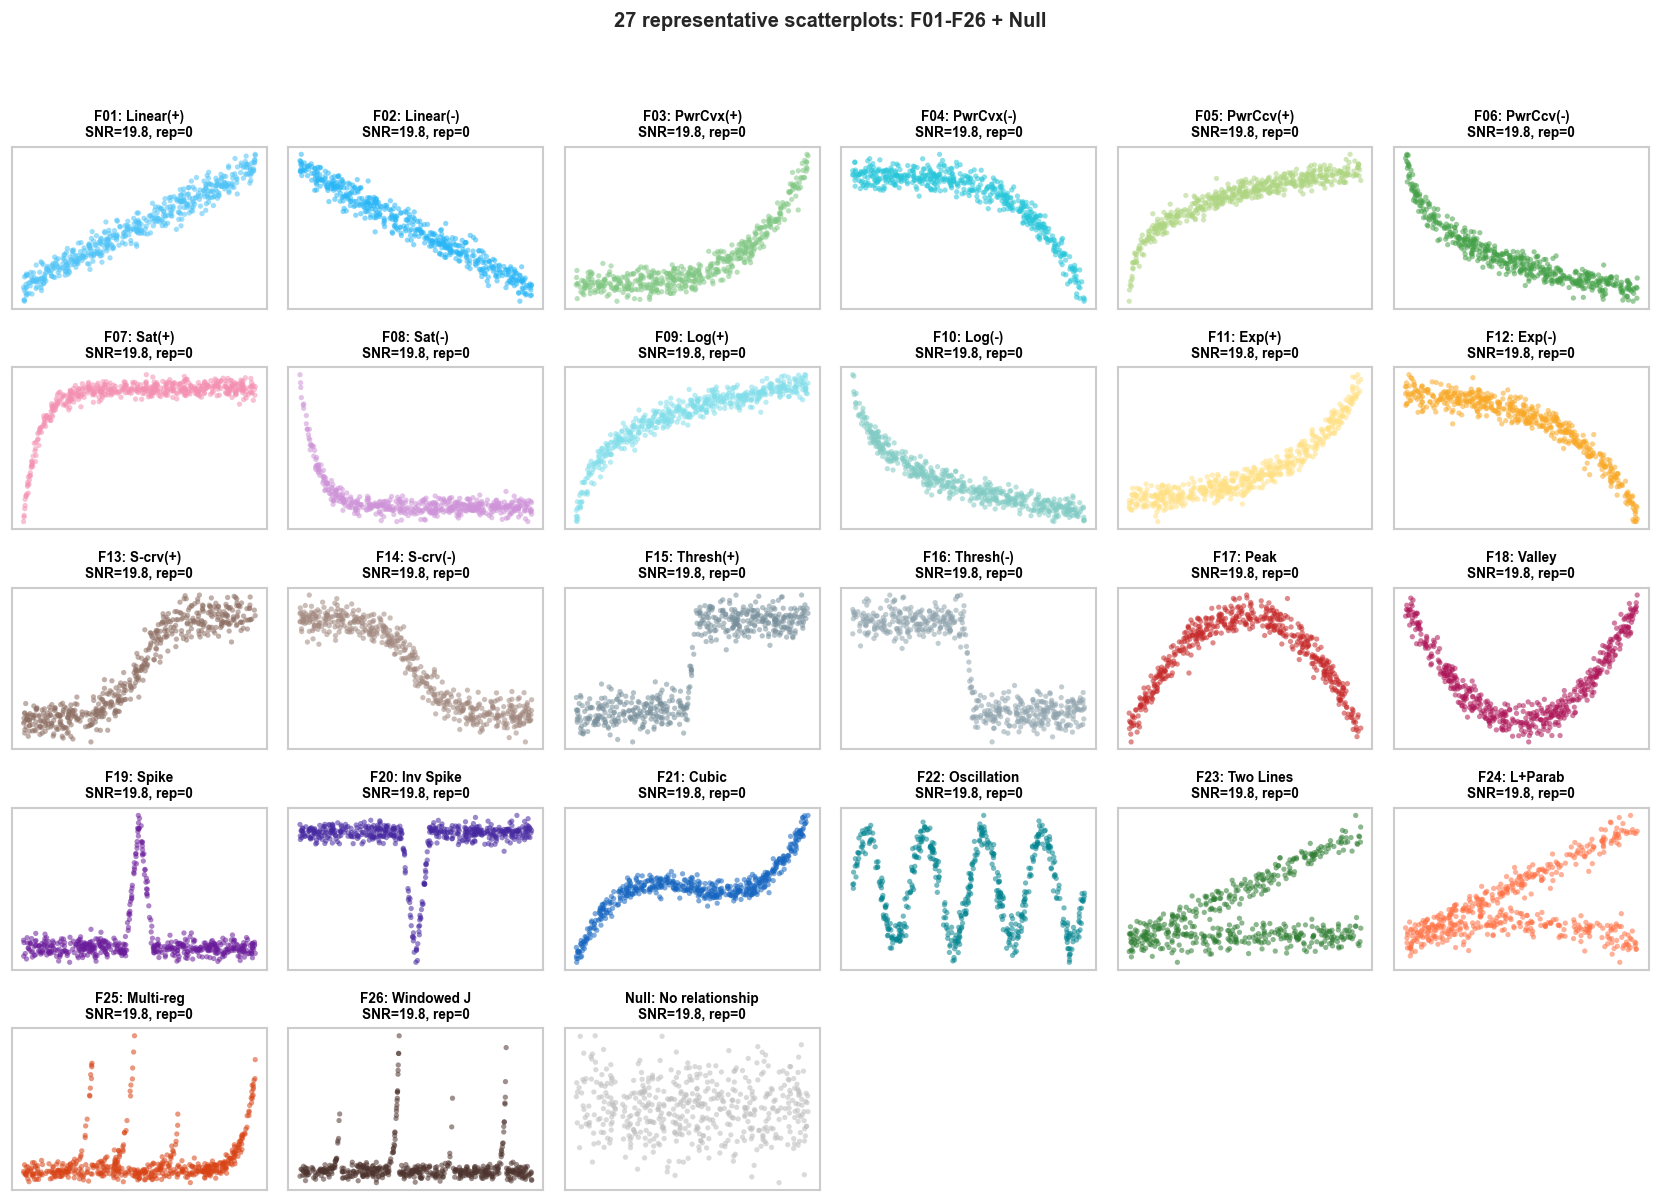

In [610]:
# ── Plot 1: raw 27 representative scatterplots ──
pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

# scatter_points.npz follows the full cases.csv row order, not the filtered df order.
case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('27 representative scatterplots: F01-F26 + Null',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    color = FAMILY_PALETTE.get(row['family_id'], '#5b9bd5')
    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=0.55,
                   color=color, edgecolors='none')
    ax.set_title(
        f"{row['family_id']}: {row['short']}\nSNR={row['snr_val']:.3g}, rep={int(row['replicate'])}",
        fontsize=8.2, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()




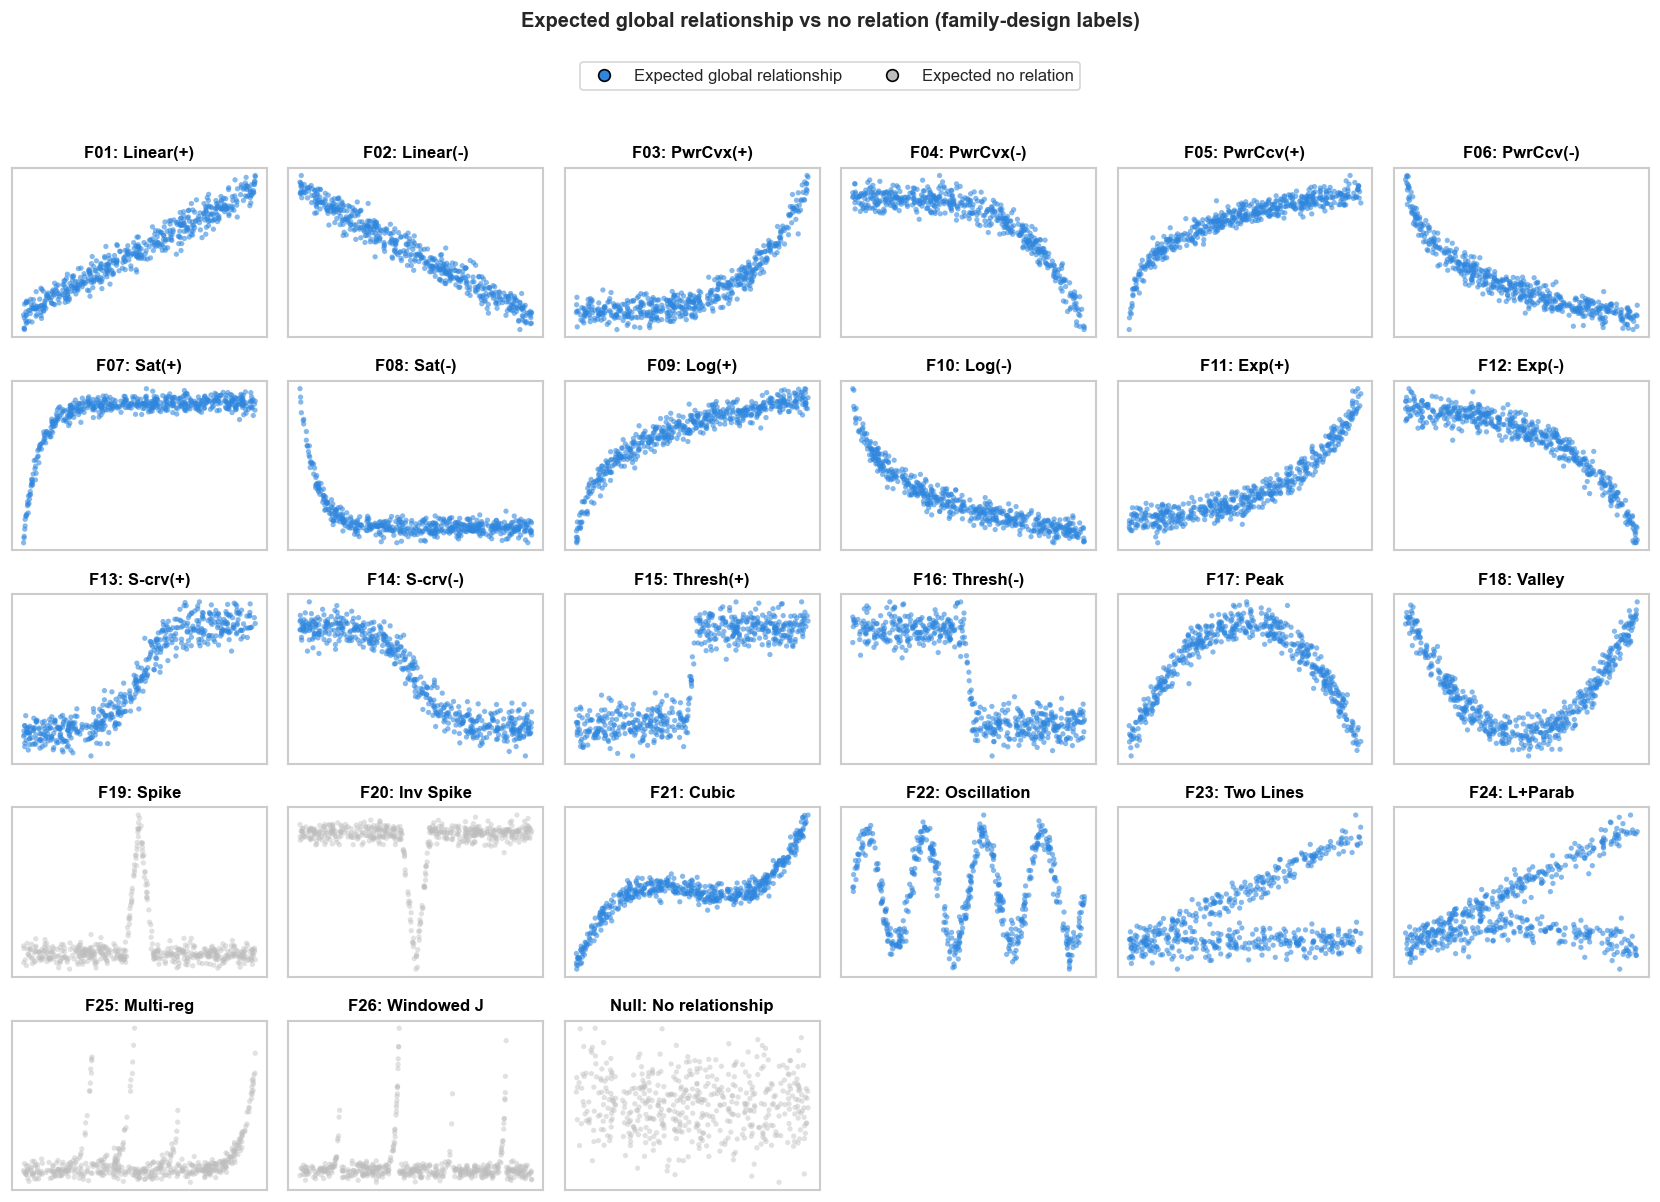

Expected no relation: ['F19', 'F20', 'F25', 'F26', 'Null']
Expected global relationship: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F21', 'F22', 'F23', 'F24']


In [611]:
# ── Expected map 1: global relationship vs no relation ──
# Expected labels from family design, before applying MIC/dcor detection.
EXPECTED_NO_REL_FIDS = {'F19', 'F20', 'F25', 'F26', 'Null'}
EXPECTED_GLOBAL_FIDS = set(FAMILY_IDS_27) - EXPECTED_NO_REL_FIDS

cases_27['expected_global_label'] = np.where(
    cases_27['family_id'].isin(EXPECTED_NO_REL_FIDS),
    'Expected no relation',
    'Expected global relationship'
)

EXPECTED_GLOBAL_COLORS = {
    'Expected global relationship': '#2E86DE',
    'Expected no relation': '#BDBDBD',
}

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Expected global relationship vs no relation (family-design labels)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['expected_global_label']
    color = EXPECTED_GLOBAL_COLORS[label]
    alpha = 0.58 if label == 'Expected global relationship' else 0.45

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']}: {row['short']}",
        fontsize=10.0, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in EXPECTED_GLOBAL_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print('Expected no relation:', sorted(EXPECTED_NO_REL_FIDS))
print('Expected global relationship:', sorted(EXPECTED_GLOBAL_FIDS))


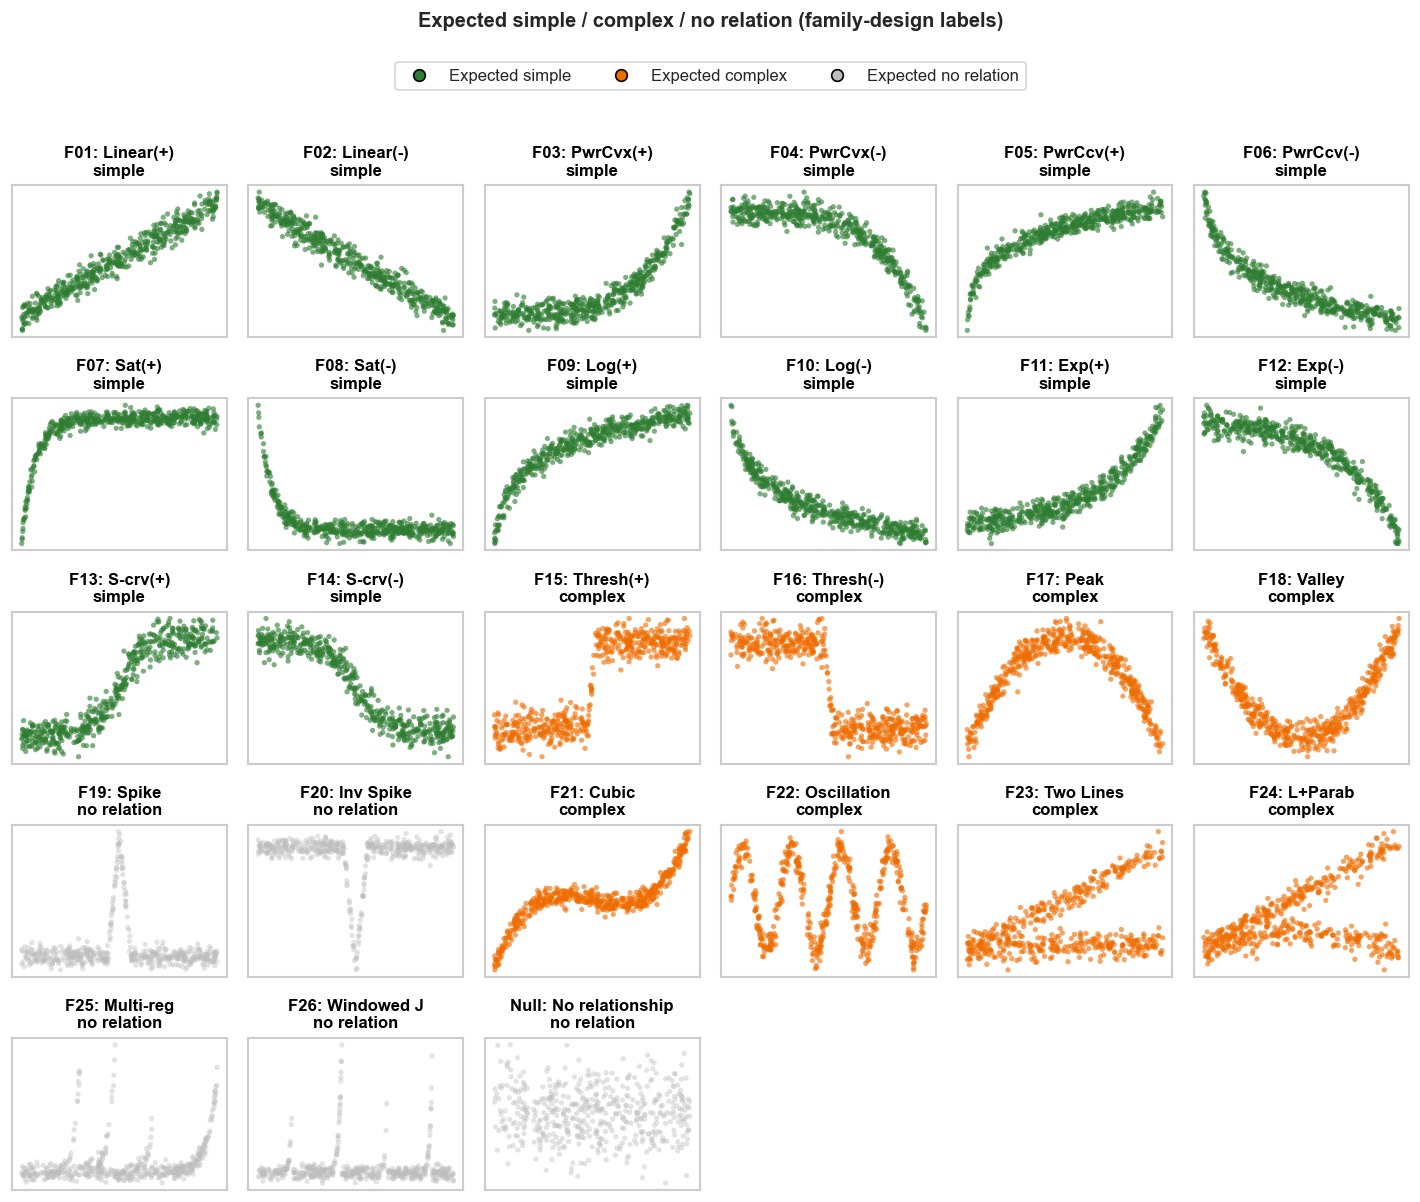

,family_id,short,expected_global_label,expected_tree_label
0,F01,Linear(+),Expected global relationship,Expected simple
1,F02,Linear(-),Expected global relationship,Expected simple
2,F03,PwrCvx(+),Expected global relationship,Expected simple
3,F04,PwrCvx(-),Expected global relationship,Expected simple
4,F05,PwrCcv(+),Expected global relationship,Expected simple
5,F06,PwrCcv(-),Expected global relationship,Expected simple
6,F07,Sat(+),Expected global relationship,Expected simple
7,F08,Sat(-),Expected global relationship,Expected simple
8,F09,Log(+),Expected global relationship,Expected simple
9,F10,Log(-),Expected global relationship,Expected simple


In [612]:
# ── Expected map 2: simple vs complex on the expected global map ──
# Simple relationship = single-regime, continuous, monotonic dominant trend.
# Complex relationship = non-monotone, multi-regime, branching, oscillation, threshold, or structural change.
EXPECTED_SIMPLE_FIDS = {
    'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08',
    'F09', 'F10', 'F11', 'F12', 'F13', 'F14',
}
EXPECTED_COMPLEX_FIDS = {'F15', 'F16', 'F17', 'F18', 'F21', 'F22', 'F23', 'F24'}
EXPECTED_NO_REL_FIDS = {'F19', 'F20', 'F25', 'F26', 'Null'}

cases_27['expected_tree_label'] = np.select(
    [
        cases_27['family_id'].isin(EXPECTED_SIMPLE_FIDS),
        cases_27['family_id'].isin(EXPECTED_COMPLEX_FIDS),
        cases_27['family_id'].isin(EXPECTED_NO_REL_FIDS),
    ],
    ['Expected simple', 'Expected complex', 'Expected no relation'],
    default='Expected unassigned'
)

EXPECTED_TREE_COLORS = {
    'Expected simple': '#2E7D32',
    'Expected complex': '#EF6C00',
    'Expected no relation': '#BDBDBD',
    'Expected unassigned': '#757575',
}

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Expected simple / complex / no relation (family-design labels)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['expected_tree_label']
    color = EXPECTED_TREE_COLORS[label]
    alpha = 0.62 if label != 'Expected no relation' else 0.42

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']}: {row['short']}\n{label.replace('Expected ', '')}",
        fontsize=10, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in EXPECTED_TREE_COLORS.items()
           if k in set(cases_27['expected_tree_label'])]
fig.legend(handles=handles, loc='upper center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

display(cases_27[['family_id', 'short', 'expected_global_label', 'expected_tree_label']])


## Step 1 — Global Relationship

`MIC >= threshold AND distance_correlation >= threshold`

Null is kept as its own baseline category.

In [613]:
# ── Step 1: Global Relationship ──
MIC_THRESH = 0.8
DCOR_THRESH = 0

cases_27['pass_MIC'] = cases_27['MIC'] >= MIC_THRESH
cases_27['pass_dcor'] = cases_27['distance_correlation'] >= DCOR_THRESH
cases_27['global_relationship'] = (
    (cases_27['family_id'] != 'Null') &
    cases_27['pass_MIC'] &
    cases_27['pass_dcor']
)

cases_27['global_label'] = np.where(
    cases_27['family_id'] == 'Null',
    'Null',
    np.where(cases_27['global_relationship'], 'Global relationship', 'No global relationship')
)

global_cases = cases_27[cases_27['global_relationship']].copy()

print('═══ Step 1: Global Relationship ═══')
print(f'Rule: MIC >= {MIC_THRESH} AND dcor >= {DCOR_THRESH}')
print(f'Global relationship: {len(global_cases)} / 26 signal families')
print()
print(cases_27['global_label'].value_counts().to_string())

display(cases_27[[
    'family_id', 'short', 'MIC', 'distance_correlation',
    'pass_MIC', 'pass_dcor', 'global_label',
]].round(3))

═══ Step 1: Global Relationship ═══
Rule: MIC >= 0.8 AND dcor >= 0
Global relationship: 17 / 26 signal families

global_label
Global relationship       17
No global relationship     9
Null                       1


,family_id,short,MIC,distance_correlation,pass_MIC,pass_dcor,global_label
0,F01,Linear(+),0.944,0.973,True,True,Global relationship
1,F02,Linear(-),0.967,0.973,True,True,Global relationship
2,F03,PwrCvx(+),0.830,0.864,True,True,Global relationship
3,F04,PwrCvx(-),0.803,0.870,True,True,Global relationship
4,F05,PwrCcv(+),0.842,0.926,True,True,Global relationship
5,F06,PwrCcv(-),0.862,0.926,True,True,Global relationship
6,F07,Sat(+),0.558,0.642,False,True,No global relationship
7,F08,Sat(-),0.550,0.617,False,True,No global relationship
8,F09,Log(+),0.887,0.921,True,True,Global relationship
9,F10,Log(-),0.883,0.926,True,True,Global relationship


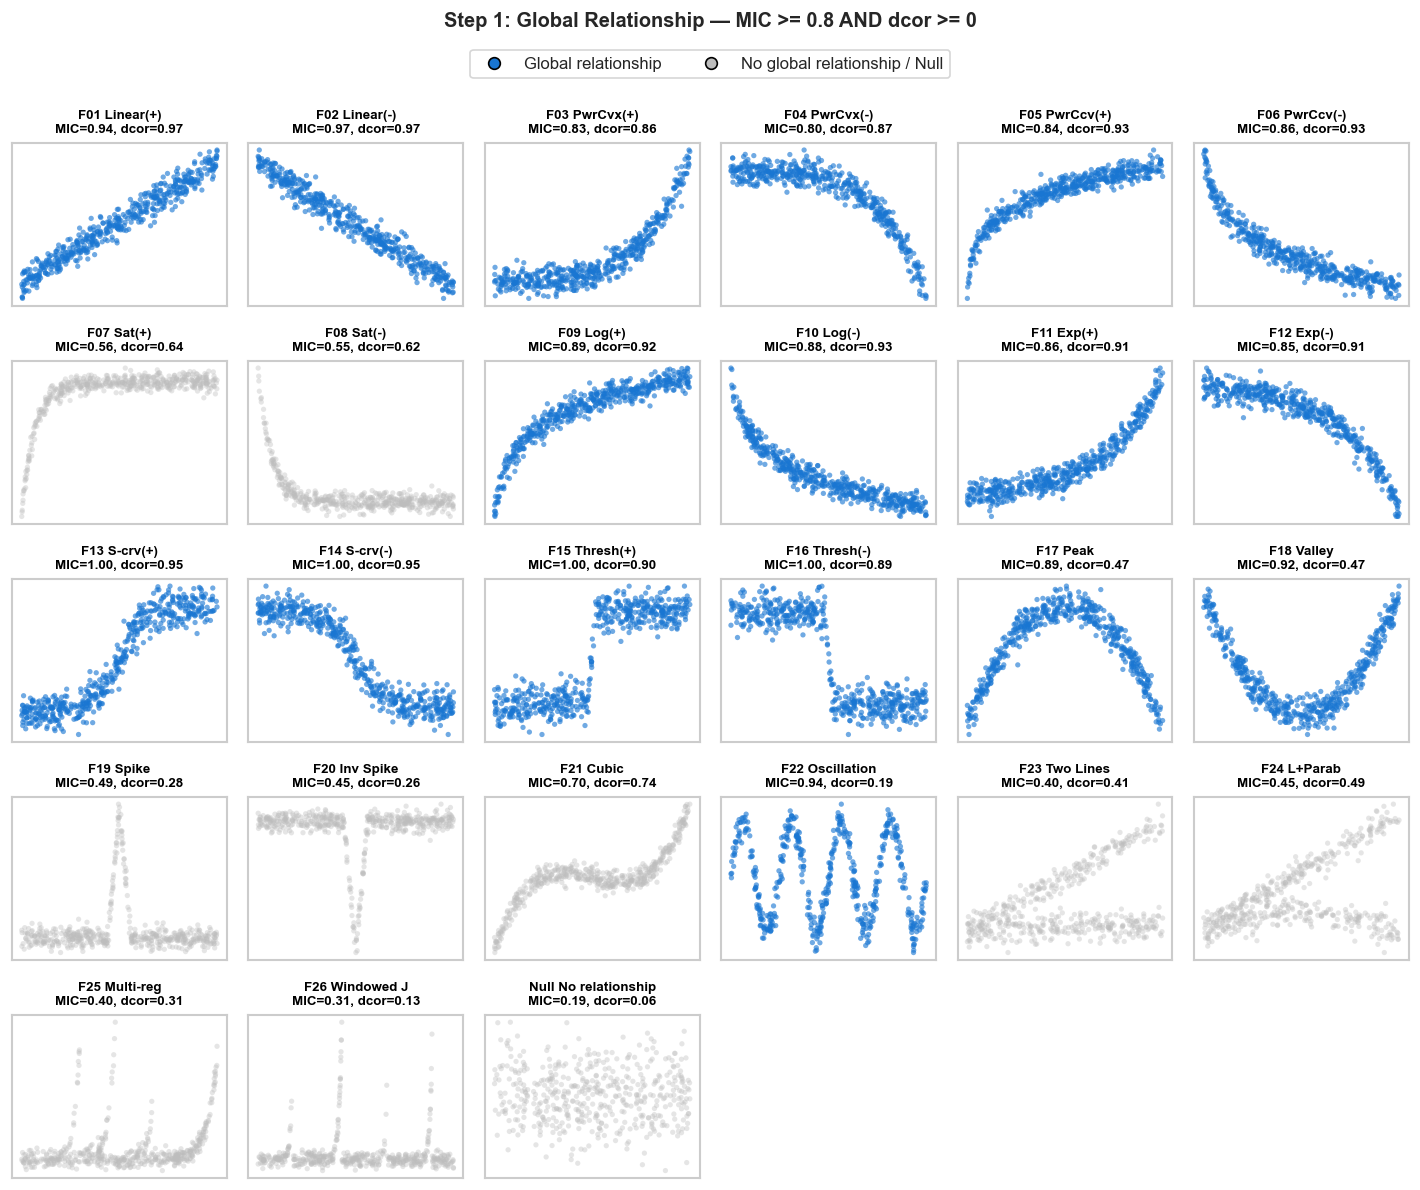

In [614]:
# ── Plot Step 1: Global relationship ──
if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle(f'Step 1: Global Relationship — MIC >= {MIC_THRESH} AND dcor >= {DCOR_THRESH}',
             fontsize=12, fontweight='bold', y=0.99)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    is_global = bool(row['global_relationship'])
    color = C_GLOBAL if is_global else C_NO_REL
    alpha = 0.62 if is_global else 0.38

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']} {row['short']}\nMIC={row['MIC']:.2f}, dcor={row['distance_correlation']:.2f}",
        fontsize=8.0, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [
    Line2D([0],[0], marker='o', color='none', markerfacecolor=C_GLOBAL, markersize=7, label='Global relationship'),
    Line2D([0],[0], marker='o', color='none', markerfacecolor=C_NO_REL, markersize=7, label='No global relationship / Null'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [615]:
# (Removed: duplicate Step 1 plot)

## Step 2 — Simple vs Complex

Run only on cases that passed Step 1.

Base: `|ρ| >= 0.7 AND |r| >= 0.7`
Optional gates (toggleable):
- `MAS < 0.10` — non-monotonicity filter
- `MIC-r² < 0.20` — non-linearity filter (catches threshold-type)
- **Slope sign-change gate** — bin raw scatter data into N bins, compute slope per bin, count adjacent sign changes (with prominence filter).
  - `N_SLOPE_BINS`: number of bins (default 5)
  - `BIN_MODE`: `equal_count` (quantile) or `equal_width`
  - `MAX_SIGN_CHANGES`: max allowed sign changes (default 0 = strict)
  - `USE_PROMINENCE_FILTER`: toggle prominence filtering on/off
  - `MIN_REVERSAL_PROMINENCE`: minimum `|slope_right| / |slope_left|` for a sign change to count (default 0.1). Compares with left neighbor.

In [ ]:
# ── Step 2: Simple vs Complex ──
R_THRESH = 0.7

USE_REV_GATE = False
REVERSAL_PROMINENCE = 0.10

USE_MAS_GATE = False
MAS_THRESH = 0.10

USE_MR_GATE = False
MR_THRESH = 0.20

USE_SIGN_CHANGE_GATE = True
MAX_SIGN_CHANGES = 1          # 0 = strict (no turning point allowed)
N_SLOPE_BINS = 3              # number of bins for slope computation
BIN_MODE = 'equal_count'      # 'equal_count' (quantile) or 'equal_width'
USE_PROMINENCE_FILTER = False  # filter out noise sign changes by neighbor ratio
MIN_REVERSAL_PROMINENCE = 0.1 # |slope_right| / |slope_left| must exceed this

def compute_reversal_prominence(frame):
    e = frame['standardized_polyfit_early_slope'].to_numpy(dtype=float)
    m = frame['standardized_polyfit_middle_slope'].to_numpy(dtype=float)
    l = frame['standardized_polyfit_late_slope'].to_numpy(dtype=float)

    sign_e, sign_m, sign_l = np.sign(e), np.sign(m), np.sign(l)
    has_sign_change = ~((sign_e == sign_m) & (sign_m == sign_l))

    abs_max = np.maximum(np.maximum(np.abs(e), np.abs(m)), np.abs(l))
    abs_max = np.where(abs_max == 0, 1, abs_max)
    maj_sign = np.sign(e + m + l)

    rev_prom = np.zeros(len(frame))
    for i in range(len(frame)):
        if not has_sign_change[i] or maj_sign[i] == 0:
            continue
        rev_vals = [abs(s) for s in [e[i], m[i], l[i]]
                    if np.sign(s) != maj_sign[i] and np.sign(s) != 0]
        if rev_vals:
            rev_prom[i] = max(rev_vals) / abs_max[i]
    return rev_prom, has_sign_change

sc = global_cases.copy()
sc['pass_spearman'] = sc['spearman_rho'].abs() >= R_THRESH
sc['pass_pearson'] = sc['pearson_r'].abs() >= R_THRESH

sc['pass_MAS'] = sc['MAS'] < MAS_THRESH if USE_MAS_GATE else True
sc['pass_MR'] = sc['MIC_minus_r2'] < MR_THRESH if USE_MR_GATE else True

# ── Binned slope sign-change detection (from raw scatter data) ──
if USE_SIGN_CHANGE_GATE:
    _pts = np.load(S1_DIR / 'scatter_points.npz')
    _x_raw, _y_raw = _pts['x'], _pts['y']
    _cidx = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()
    _idx = np.array([_cidx[cid] for cid in sc['case_id'].values])
    _x = _x_raw[_idx]
    _y = _y_raw[_idx]

    _srt = np.argsort(_x, axis=1)
    _xs = np.take_along_axis(_x, _srt, axis=1)
    _ys = np.take_along_axis(_y, _srt, axis=1)
    n_pts = _xs.shape[1]

    bin_slopes = np.zeros((len(sc), N_SLOPE_BINS))

    if BIN_MODE == 'equal_count':
        edges = np.linspace(0, n_pts, N_SLOPE_BINS + 1, dtype=int)
        for b in range(N_SLOPE_BINS):
            xb = _xs[:, edges[b]:edges[b+1]]
            yb = _ys[:, edges[b]:edges[b+1]]
            nb = edges[b+1] - edges[b]
            sx  = xb.sum(axis=1)
            sy  = yb.sum(axis=1)
            sxy = (xb * yb).sum(axis=1)
            sx2 = (xb ** 2).sum(axis=1)
            denom = nb * sx2 - sx ** 2
            denom = np.where(denom == 0, 1, denom)
            bin_slopes[:, b] = (nb * sxy - sx * sy) / denom
    else:  # equal_width
        _xmin = _xs[:, [0]]
        _xrng = _xs[:, [-1]] - _xmin
        _xrng = np.where(_xrng == 0, 1, _xrng)
        _xn = (_xs - _xmin) / _xrng
        for b in range(N_SLOPE_BINS):
            lo = b / N_SLOPE_BINS
            hi = (b + 1) / N_SLOPE_BINS
            mask = (_xn >= lo) & (_xn < hi) if b < N_SLOPE_BINS - 1 else (_xn >= lo)
            nb  = mask.sum(axis=1).astype(float)
            sx  = np.where(mask, _xs, 0).sum(axis=1)
            sy  = np.where(mask, _ys, 0).sum(axis=1)
            sxy = np.where(mask, _xs * _ys, 0).sum(axis=1)
            sx2 = np.where(mask, _xs ** 2, 0).sum(axis=1)
            denom = nb * sx2 - sx ** 2
            valid = (nb >= 2) & (denom != 0)
            denom = np.where(valid, denom, 1)
            bin_slopes[:, b] = np.where(valid, (nb * sxy - sx * sy) / denom, 0)

    signs = np.sign(bin_slopes)
    sign_diffs = np.diff(signs, axis=1)
    has_change = sign_diffs != 0

    # Prominence filter: compare with left neighbor
    if USE_PROMINENCE_FILTER:
        abs_left  = np.abs(bin_slopes[:, :-1])
        abs_right = np.abs(bin_slopes[:, 1:])
        abs_left_safe = np.where(abs_left == 0, 1, abs_left)
        prominent = (abs_right / abs_left_safe) >= MIN_REVERSAL_PROMINENCE
    else:
        prominent = np.ones_like(has_change, dtype=bool)

    n_sign_changes = (has_change & prominent).sum(axis=1)
    sc['n_sign_changes'] = n_sign_changes
    sc['pass_sign_change'] = n_sign_changes <= MAX_SIGN_CHANGES

    del _pts, _x_raw, _y_raw, _x, _y, _xs, _ys
    prom_label = f', prom≥{MIN_REVERSAL_PROMINENCE} (neighbor)' if USE_PROMINENCE_FILTER else ''
    print(f'  Sign-change gate: {N_SLOPE_BINS} bins, mode={BIN_MODE}, max_changes={MAX_SIGN_CHANGES}{prom_label}')
else:
    sc['pass_sign_change'] = True
    sc['n_sign_changes'] = 0

rev_prom, has_sign_change = compute_reversal_prominence(sc)
sc['has_slope_sign_change'] = has_sign_change
sc['reversal_prominence'] = rev_prom
if USE_REV_GATE:
    sc['pass_no_reversal'] = ~(sc['has_slope_sign_change'] & (sc['reversal_prominence'] >= REVERSAL_PROMINENCE))
else:
    sc['pass_no_reversal'] = True

sc['is_simple'] = sc['pass_spearman'] & sc['pass_pearson'] & sc['pass_MAS'] & sc['pass_MR'] & sc['pass_sign_change'] & sc['pass_no_reversal']

cases_27 = cases_27.merge(
    sc[['case_id', 'pass_spearman', 'pass_pearson', 'pass_MAS', 'pass_MR',
        'n_sign_changes', 'pass_sign_change',
        'has_slope_sign_change', 'reversal_prominence', 'pass_no_reversal', 'is_simple']],
    on='case_id', how='left'
)

cases_27['simple_complex_label'] = np.select(
    [cases_27['family_id'] == 'Null',
     ~cases_27['global_relationship'],
     cases_27['is_simple'].fillna(False)],
    ['Null', 'No global relationship', 'Simple'],
    default='Complex'
)

rule_parts = [f'|ρ| ≥ {R_THRESH}', f'|r| ≥ {R_THRESH}']
if USE_MAS_GATE: rule_parts.append(f'MAS < {MAS_THRESH}')
if USE_MR_GATE:  rule_parts.append(f'MIC-r² < {MR_THRESH}')
if USE_SIGN_CHANGE_GATE:
    sc_desc = f'sign_changes ≤ {MAX_SIGN_CHANGES} ({N_SLOPE_BINS}bins, {BIN_MODE}'
    if USE_PROMINENCE_FILTER:
        sc_desc += f', prom≥{MIN_REVERSAL_PROMINENCE}'
    sc_desc += ')'
    rule_parts.append(sc_desc)
if USE_REV_GATE: rule_parts.append(f'RevProm < {REVERSAL_PROMINENCE}')
rule_str = ' AND '.join(rule_parts)

print('═══ Step 2: Simple vs Complex ═══')
print(f'Rule: {rule_str}')
print(f'Gates: MAS={USE_MAS_GATE}, MIC-r²={USE_MR_GATE}, sign_change={USE_SIGN_CHANGE_GATE}, prominence={USE_PROMINENCE_FILTER}, Reversal={USE_REV_GATE}')
print()
print(cases_27['simple_complex_label'].value_counts().to_string())

display(cases_27[[
    'family_id', 'short', 'global_label', 'spearman_rho', 'pearson_r', 'MAS', 'MIC_minus_r2',
    'standardized_polyfit_early_slope', 'standardized_polyfit_middle_slope',
    'standardized_polyfit_late_slope', 'reversal_prominence',
    'n_sign_changes', 'pass_sign_change',
    'pass_spearman', 'pass_pearson', 'pass_MAS', 'pass_MR', 'pass_no_reversal',
    'simple_complex_label',
]].round(3))

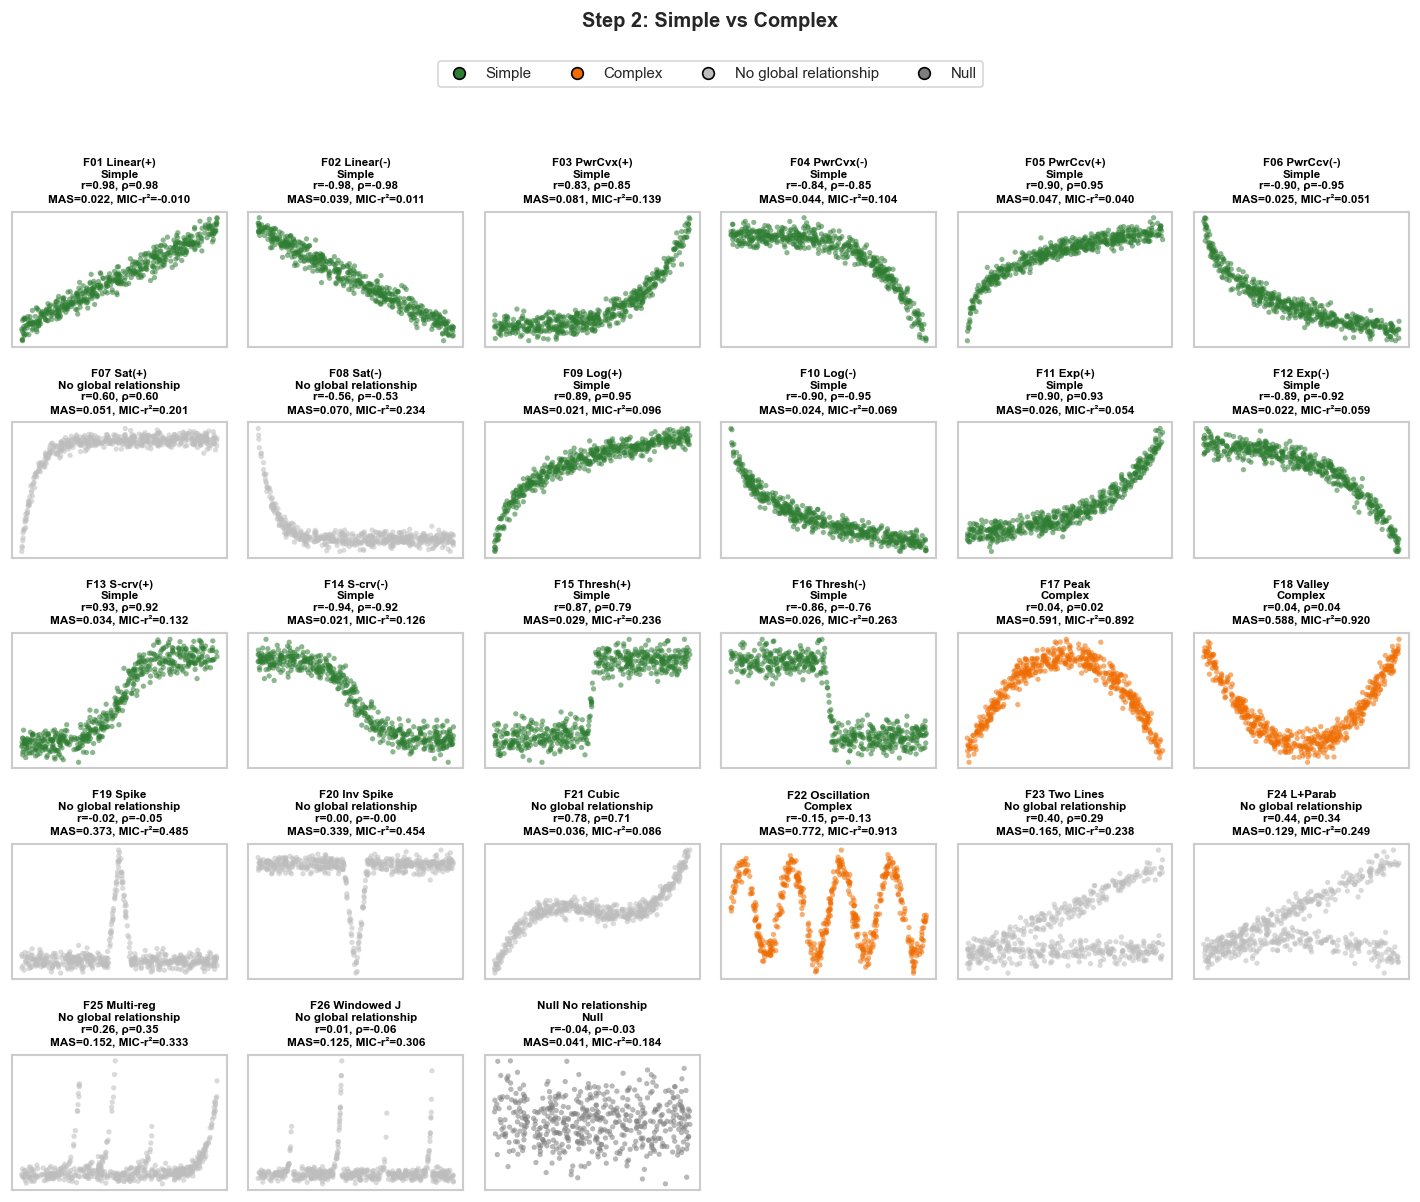

In [617]:
# ── Plot Step 2: Simple vs Complex ──
fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Step 2: Simple vs Complex', fontsize=12, fontweight='bold', y=1.0)

SC_MAP = {'Simple': C_SIMPLE, 'Complex': C_COMPLEX, 'No global relationship': C_NO_REL, 'Null': C_NULL}

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['simple_complex_label']
    color = SC_MAP[label]
    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=0.55, color=color, edgecolors='none')
    ax.set_title(
        f"{row['family_id']} {row['short']}\n{label}\n"
        f"r={row['pearson_r']:.2f}, ρ={row['spearman_rho']:.2f}\n"
        f"MAS={row['MAS']:.3f}, MIC-r²={row['MIC_minus_r2']:.3f}",
        fontsize=7.0, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=v, markersize=7, label=k)
           for k, v in SC_MAP.items()]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 3 — Direction

Sign of Pearson r. Only applies to Simple cases.

In [618]:
# ── Step 3: Direction ──
simple_cases_27 = cases_27[cases_27['simple_complex_label'] == 'Simple'].copy()

simple_cases_27['direction_tree'] = np.where(
    simple_cases_27['pearson_r'] > 0, 'Positive', 'Negative'
)

print('═══ Step 3: Direction (sign of Pearson r) ═══')
print(f'Simple cases: {len(simple_cases_27)}')
print()
print(simple_cases_27['direction_tree'].value_counts().to_string())
print()
display(simple_cases_27[['family_id', 'short', 'pearson_r', 'direction_tree']].round(3))

═══ Step 3: Direction (sign of Pearson r) ═══
Simple cases: 14

direction_tree
Positive    7
Negative    7



,family_id,short,pearson_r,direction_tree
0,F01,Linear(+),0.977,Positive
1,F02,Linear(-),-0.978,Negative
2,F03,PwrCvx(+),0.832,Positive
3,F04,PwrCvx(-),-0.836,Negative
4,F05,PwrCcv(+),0.896,Positive
5,F06,PwrCcv(-),-0.901,Negative
8,F09,Log(+),0.889,Positive
9,F10,Log(-),-0.902,Negative
10,F11,Exp(+),0.896,Positive
11,F12,Exp(-),-0.890,Negative


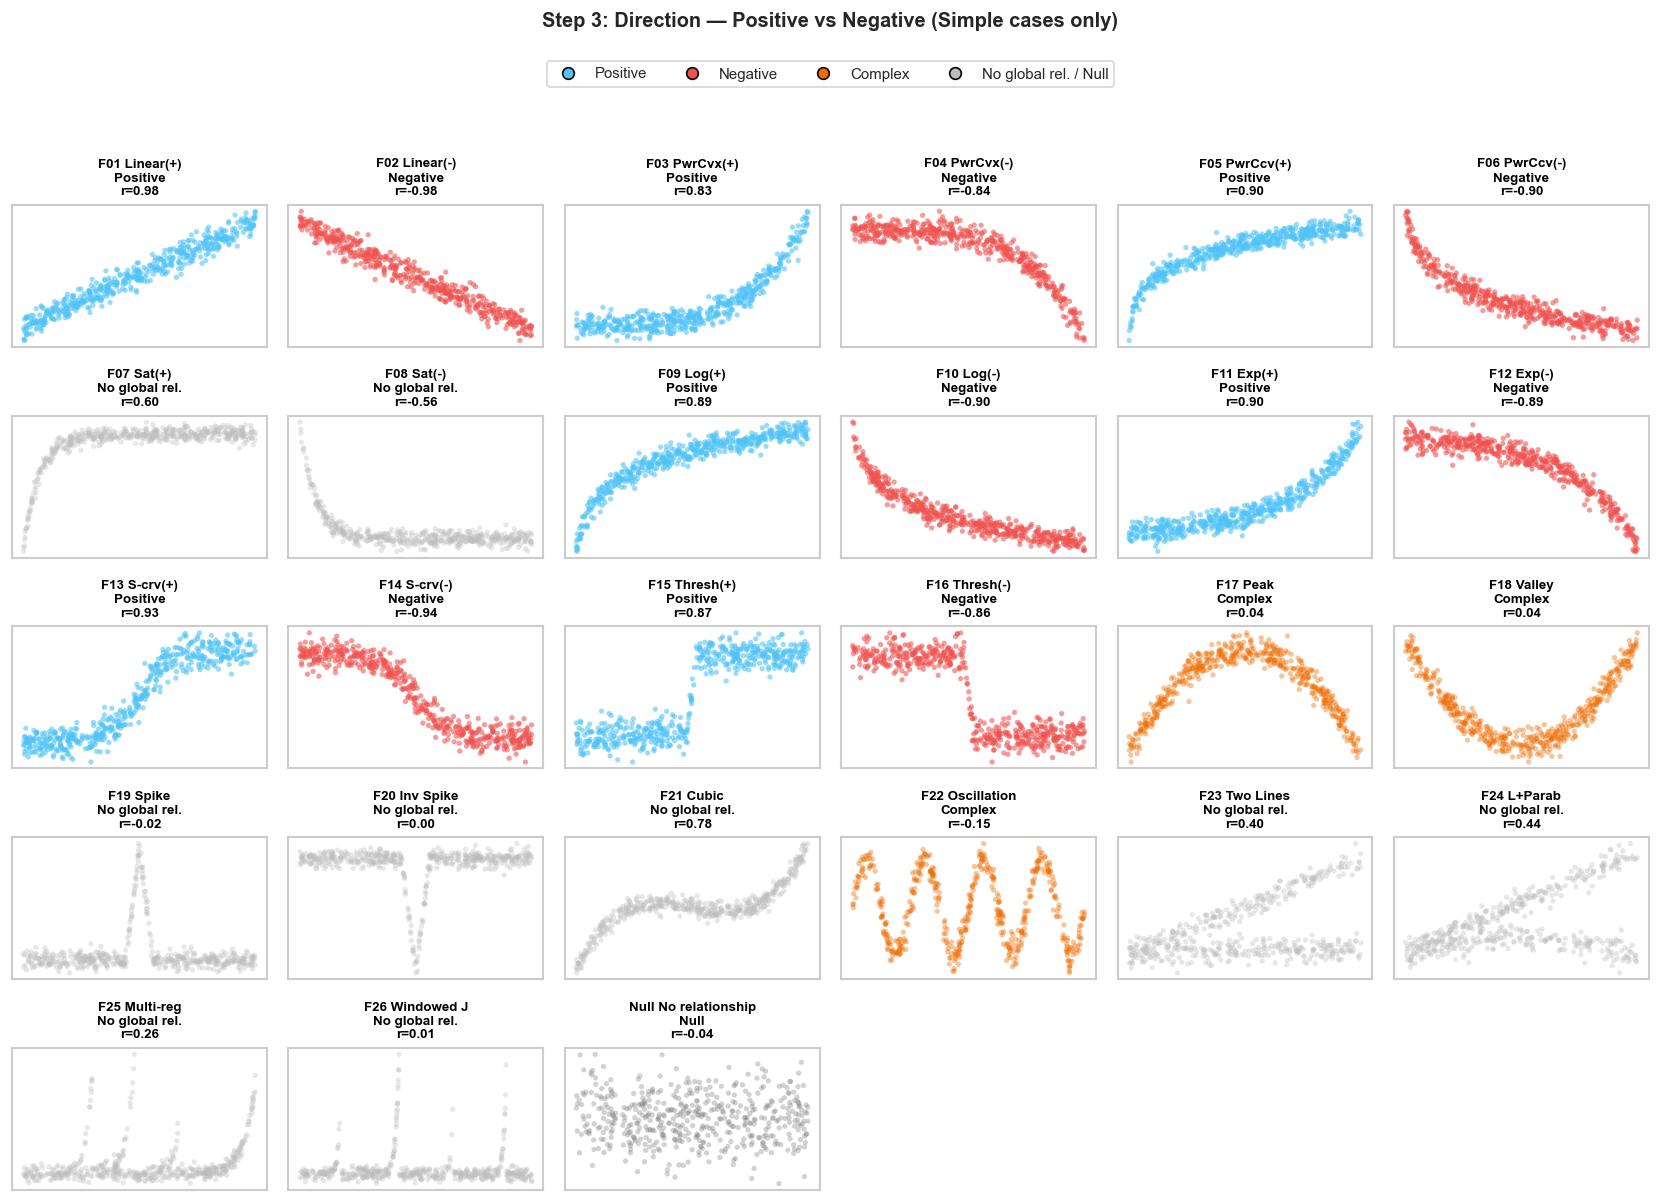

In [619]:
# ── Plot Step 3: Direction ──
cases_27 = cases_27.drop(columns=['direction_tree'], errors='ignore')
cases_27 = cases_27.merge(simple_cases_27[['case_id', 'direction_tree']], on='case_id', how='left')

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Step 3: Direction — Positive vs Negative (Simple cases only)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['direction_tree']
        color = C_POS if label == 'Positive' else C_NEG
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label, color, alpha = 'Complex', C_COMPLEX, 0.40
    elif row['family_id'] == 'Null':
        label, color, alpha = 'Null', C_NULL, 0.35
    else:
        label, color, alpha = 'No global rel.', C_NO_REL, 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')
    ax.set_title(f"{row['family_id']} {row['short']}\n{label}\nr={row['pearson_r']:.2f}",
                 fontsize=8.0, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=7, label=k)
           for k, c in [('Positive', C_POS), ('Negative', C_NEG),
                         ('Complex', C_COMPLEX), ('No global rel. / Null', C_NO_REL)]]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 4 — Monotonicity

|Spearman ρ| level: **Strong** (≥ 0.9) vs **Med** (< 0.9).
Optional gate: MAS < threshold (asymmetry filter).

In [620]:
# ── Step 4: Monotonicity ──
MONO_STRONG = 0.9

USE_MAS_GATE = False
MAS_THRESH = 0.20

cond_rho_strong = simple_cases_27['spearman_rho'].abs() >= MONO_STRONG
cond_mas = (simple_cases_27['MAS'] < MAS_THRESH) if USE_MAS_GATE else True

simple_cases_27['monotonicity_tree'] = np.where(
    cond_rho_strong & cond_mas, 'Strong', 'Med'
)

print(f'═══ Step 4: Monotonicity ═══')
rule_parts = [f'|ρ| ≥ {MONO_STRONG}']
if USE_MAS_GATE: rule_parts.append(f'MAS < {MAS_THRESH}')
print(f'Rule: Strong = {" AND ".join(rule_parts)}')
print(f'Gates: USE_MAS_GATE={USE_MAS_GATE}')
print()
print(simple_cases_27['monotonicity_tree'].value_counts().to_string())
print()
cols = ['family_id', 'short', 'spearman_rho', 'direction_tree', 'monotonicity_tree']
if USE_MAS_GATE: cols.insert(3, 'MAS')
display(simple_cases_27[cols].round(3))

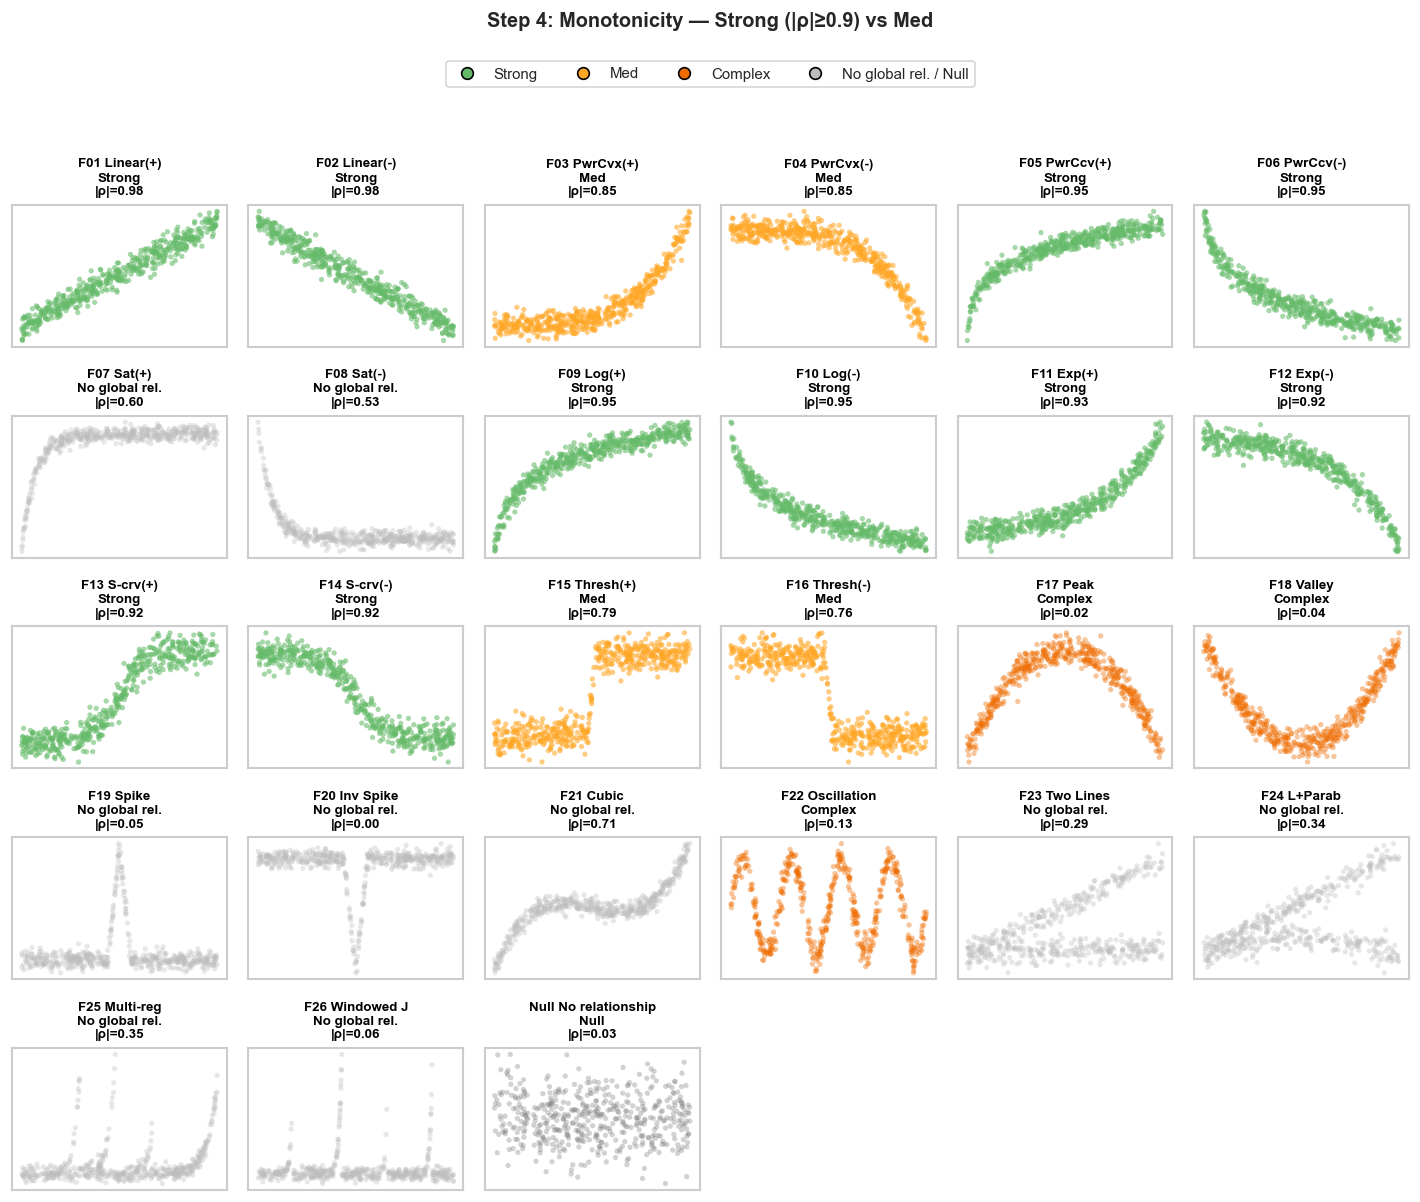

In [629]:
# ── Plot Step 4: Monotonicity ──
cases_27 = cases_27.drop(columns=['monotonicity_tree'], errors='ignore')
cases_27 = cases_27.merge(simple_cases_27[['case_id', 'monotonicity_tree']], on='case_id', how='left')

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle(f'Step 4: Monotonicity — Strong (|ρ|≥{MONO_STRONG}) vs Med',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['monotonicity_tree']
        color = C_MONO_S if label == 'Strong' else C_MONO_M
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label, color, alpha = 'Complex', C_COMPLEX, 0.40
    elif row['family_id'] == 'Null':
        label, color, alpha = 'Null', C_NULL, 0.35
    else:
        label, color, alpha = 'No global rel.', C_NO_REL, 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')
    ax.set_title(f"{row['family_id']} {row['short']}\n{label}\n|ρ|={abs(row['spearman_rho']):.2f}",
                 fontsize=8.0, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=7, label=k)
           for k, c in [('Strong', C_MONO_S), ('Med', C_MONO_M),
                         ('Complex', C_COMPLEX), ('No global rel. / Null', C_NO_REL)]]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 5 — Line Detection

Base: **Strong monotonicity** cases only (from Step 4).

**Line** = |r| ≥ 0.9 + slope_span < 0.20 + MIC-r² < threshold **OR/AND** V_s < threshold

MIC-r² confirms linearity: low means r² already explains what MIC captures.

In [622]:
# ── Step 5: Line Detection ──
# Base: Strong monotonicity cases only (from Step 4)
LIN_STRONG = 0.9
LINE_SPAN_TOL = 0.20
LINE_MR_THRESH = 0.2

USE_SPAN_GATE = True

USE_VS_LINE = True
LINE_VS_THRESH = 0.35
VS_LINE_MODE = 'or'        # 'or': V_s alone catches Line; 'and': V_s is extra requirement

strong_cases_27 = simple_cases_27[simple_cases_27['monotonicity_tree'] == 'Strong'].copy()

strong_cases_27['linearity_tree'] = np.where(
    strong_cases_27['pearson_r'].abs() >= LIN_STRONG, 'High |r|', 'Med |r|'
)

E_raw = strong_cases_27['standardized_polyfit_early_slope'].values
M_raw = strong_cases_27['standardized_polyfit_middle_slope'].values
L_raw = strong_cases_27['standardized_polyfit_late_slope'].values

scale = np.maximum(np.maximum(np.abs(E_raw), np.abs(M_raw)), np.abs(L_raw))
scale = np.where(scale == 0, 1, scale)
e_n, m_n, l_n = E_raw / scale, M_raw / scale, L_raw / scale

dsign = np.where(strong_cases_27['pearson_r'].values > 0, 1, -1)
e_d = e_n * dsign
m_d = m_n * dsign
l_d = l_n * dsign

strong_cases_27['e_d'] = e_d
strong_cases_27['m_d'] = m_d
strong_cases_27['l_d'] = l_d

slopes = np.column_stack([e_d, m_d, l_d])
slope_span = slopes.max(axis=1) - slopes.min(axis=1)
strong_cases_27['slope_span'] = slope_span

EPS = 1e-8
V_s = slopes.std(axis=1, ddof=0) / (np.abs(slopes.mean(axis=1)) + EPS)
strong_cases_27['slope_Vs'] = V_s

cond_classic = (
    (strong_cases_27['linearity_tree'] == 'High |r|') &
    ((strong_cases_27['slope_span'] < LINE_SPAN_TOL) if USE_SPAN_GATE else True) &
    (strong_cases_27['MIC_minus_r2'] < LINE_MR_THRESH)
)

if USE_VS_LINE:
    cond_vs = V_s < LINE_VS_THRESH
    if VS_LINE_MODE == 'or':
        strong_cases_27['is_line'] = cond_classic | cond_vs
    else:
        strong_cases_27['is_line'] = cond_classic & cond_vs
else:
    strong_cases_27['is_line'] = cond_classic

# Write back to simple_cases_27
simple_cases_27['linearity_tree'] = 'Med |r|'
simple_cases_27.loc[strong_cases_27.index, 'linearity_tree'] = strong_cases_27['linearity_tree']
for col in ['e_d', 'm_d', 'l_d', 'slope_span', 'slope_Vs']:
    simple_cases_27[col] = np.nan
    simple_cases_27.loc[strong_cases_27.index, col] = strong_cases_27[col]
simple_cases_27['is_line'] = False
simple_cases_27.loc[strong_cases_27.index, 'is_line'] = strong_cases_27['is_line']

print(f'═══ Step 5: Line Detection ═══')
rule_parts = [f'|r| ≥ {LIN_STRONG}']
if USE_SPAN_GATE: rule_parts.append(f'span < {LINE_SPAN_TOL}')
rule_parts.append(f'MIC-r² < {LINE_MR_THRESH}')
classic_str = ' + '.join(rule_parts)
if USE_VS_LINE:
    print(f'Rule: ({classic_str})')
    print(f'      {VS_LINE_MODE.upper()} V_s < {LINE_VS_THRESH}')
else:
    print(f'Rule: ({classic_str})')
print(f'Gates: USE_SPAN_GATE={USE_SPAN_GATE}, USE_VS_LINE={USE_VS_LINE}, VS_LINE_MODE={VS_LINE_MODE}')
print(f'Base: Strong monotonicity — {len(strong_cases_27)} / {len(simple_cases_27)} simple')
print(f'Line: {simple_cases_27["is_line"].sum()} / {len(strong_cases_27)} Strong cases')
print()
display(simple_cases_27[[
    'family_id', 'short', 'direction_tree', 'monotonicity_tree',
    'linearity_tree', 'pearson_r', 'spearman_rho', 'MIC_minus_r2',
    'e_d', 'm_d', 'l_d', 'slope_span', 'slope_Vs', 'is_line',
]].round(3))

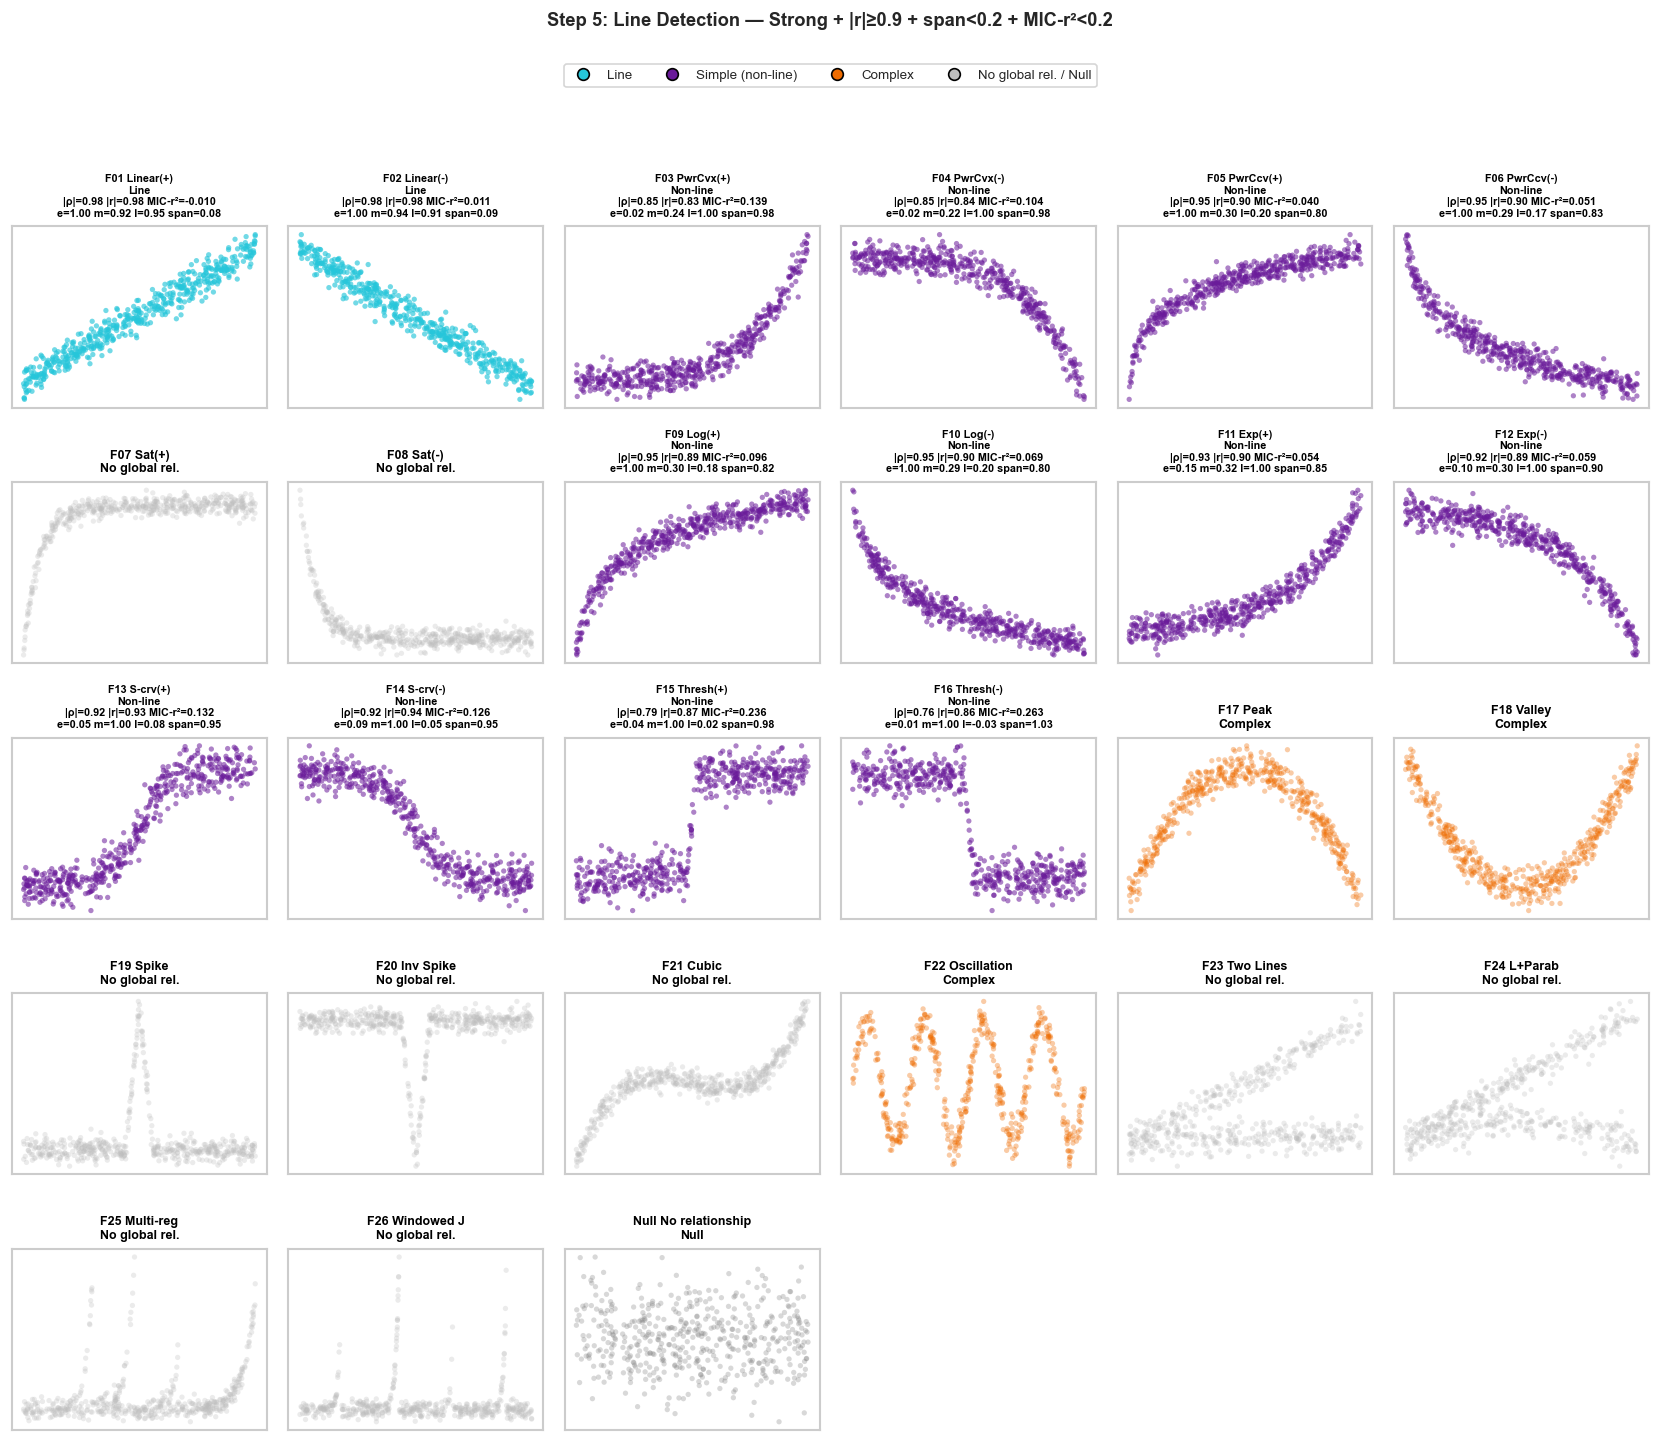

In [623]:
# ── Plot Step 5: Line Detection ──
cases_27 = cases_27.drop(columns=['linearity_tree','is_line','e_d','m_d','l_d','slope_span'], errors='ignore')
cases_27 = cases_27.merge(
    simple_cases_27[['case_id','linearity_tree','is_line','e_d','m_d','l_d','slope_span']],
    on='case_id', how='left')

fig, axes = plt.subplots(5, 6, figsize=(14, 12))
fig.suptitle(f'Step 5: Line Detection — Strong + |r|≥{LIN_STRONG} + span<{LINE_SPAN_TOL} + MIC-r²<{LINE_MR_THRESH}',
             fontsize=11, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        if row['is_line'] == True:
            label, color, alpha = 'Line', C_LINE, 0.65
        else:
            label, color, alpha = 'Non-line', C_NONLINE, 0.55
    elif row['simple_complex_label'] == 'Complex':
        label, color, alpha = 'Complex', C_COMPLEX, 0.35
    elif row['family_id'] == 'Null':
        label, color, alpha = 'Null', C_NULL, 0.30
    else:
        label, color, alpha = 'No global rel.', C_NO_REL, 0.30

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')

    if row['simple_complex_label'] == 'Simple':
        ax.set_title(
            f"{row['family_id']} {row['short']}\n{label}\n"
            f"|ρ|={abs(row['spearman_rho']):.2f} |r|={abs(row['pearson_r']):.2f} MIC-r²={row['MIC_minus_r2']:.3f}\n"
            f"e={row['e_d']:.2f} m={row['m_d']:.2f} l={row['l_d']:.2f} span={row['slope_span']:.2f}",
            fontsize=6.5, fontweight='bold', color='black')
    else:
        ax.set_title(f"{row['family_id']} {row['short']}\n{label}",
                     fontsize=7.5, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=7, label=k)
           for k, c in [('Line', C_LINE), ('Simple (non-line)', C_NONLINE),
                         ('Complex', C_COMPLEX), ('No global rel. / Null', C_NO_REL)]]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.968))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 6 — Curvature

Base: all Simple cases minus Line (Med cases + Strong non-Line cases).

Classification by E/M/L slope ordering pattern:
- **Concave**: e_d > m_d > l_d (slope decreasing — steep early, flat late)
- **Convex**: e_d < m_d < l_d (slope increasing — flat early, steep late)
- **Inflected**: m_d > e_d AND m_d > l_d (middle steepest)
- **Weak/Uncertain**: V_s too low or no clear ordering

In [624]:
# ── Step 6: Curvature ──
# Base: all Simple cases minus Line (includes Med + Strong non-Line)
USE_VS_GATE = True
CURVE_VS_MIN = 0.35

non_line_27 = simple_cases_27[~simple_cases_27['is_line']].copy()

# Compute e_d/m_d/l_d/V_s for cases that don't have them yet (Med cases)
need_slopes = non_line_27['e_d'].isna()
if need_slopes.any():
    idx_need = non_line_27[need_slopes].index
    E_raw = non_line_27.loc[idx_need, 'standardized_polyfit_early_slope'].values
    M_raw = non_line_27.loc[idx_need, 'standardized_polyfit_middle_slope'].values
    L_raw = non_line_27.loc[idx_need, 'standardized_polyfit_late_slope'].values
    scale = np.maximum(np.maximum(np.abs(E_raw), np.abs(M_raw)), np.abs(L_raw))
    scale = np.where(scale == 0, 1, scale)
    e_n, m_n, l_n = E_raw / scale, M_raw / scale, L_raw / scale
    dsign = np.where(non_line_27.loc[idx_need, 'pearson_r'].values > 0, 1, -1)
    non_line_27.loc[idx_need, 'e_d'] = e_n * dsign
    non_line_27.loc[idx_need, 'm_d'] = m_n * dsign
    non_line_27.loc[idx_need, 'l_d'] = l_n * dsign
    sl = np.column_stack([e_n * dsign, m_n * dsign, l_n * dsign])
    EPS = 1e-8
    non_line_27.loc[idx_need, 'slope_Vs'] = sl.std(axis=1, ddof=0) / (np.abs(sl.mean(axis=1)) + EPS)

e_d = non_line_27['e_d'].values
m_d = non_line_27['m_d'].values
l_d = non_line_27['l_d'].values
V_s = non_line_27['slope_Vs'].values

shape = np.full(len(non_line_27), 'Weak/Uncertain', dtype=object)

if USE_VS_GATE:
    curve_ready = V_s >= CURVE_VS_MIN
else:
    curve_ready = np.ones(len(non_line_27), dtype=bool)

shape[curve_ready & (e_d > m_d) & (m_d > l_d)] = 'Concave'
shape[curve_ready & (e_d < m_d) & (m_d < l_d)] = 'Convex'
shape[curve_ready & (m_d > e_d) & (m_d > l_d)] = 'Inflected'

non_line_27['shape_tree'] = shape

# Write back to simple_cases_27
simple_cases_27['shape_tree'] = 'Line'
simple_cases_27.loc[non_line_27.index, 'shape_tree'] = non_line_27['shape_tree']

print('═══ Step 6: Curvature ═══')
print(f'Concave:   e_d > m_d > l_d (slope decreasing)')
print(f'Convex:    e_d < m_d < l_d (slope increasing)')
print(f'Inflected: m_d > e_d AND m_d > l_d (middle steepest)')
print(f'Gate: USE_VS_GATE={USE_VS_GATE}' + (f', V_s ≥ {CURVE_VS_MIN}' if USE_VS_GATE else ' (no V_s filter)'))
print(f'Base: Non-Line Simple — {len(non_line_27)} / {len(simple_cases_27)} simple')
print()
print(simple_cases_27['shape_tree'].value_counts().to_string())
print()
display(simple_cases_27[[
    'family_id', 'short', 'direction_tree', 'monotonicity_tree',
    'is_line', 'shape_tree',
    'e_d', 'm_d', 'l_d', 'slope_span', 'slope_Vs',
]].round(3))

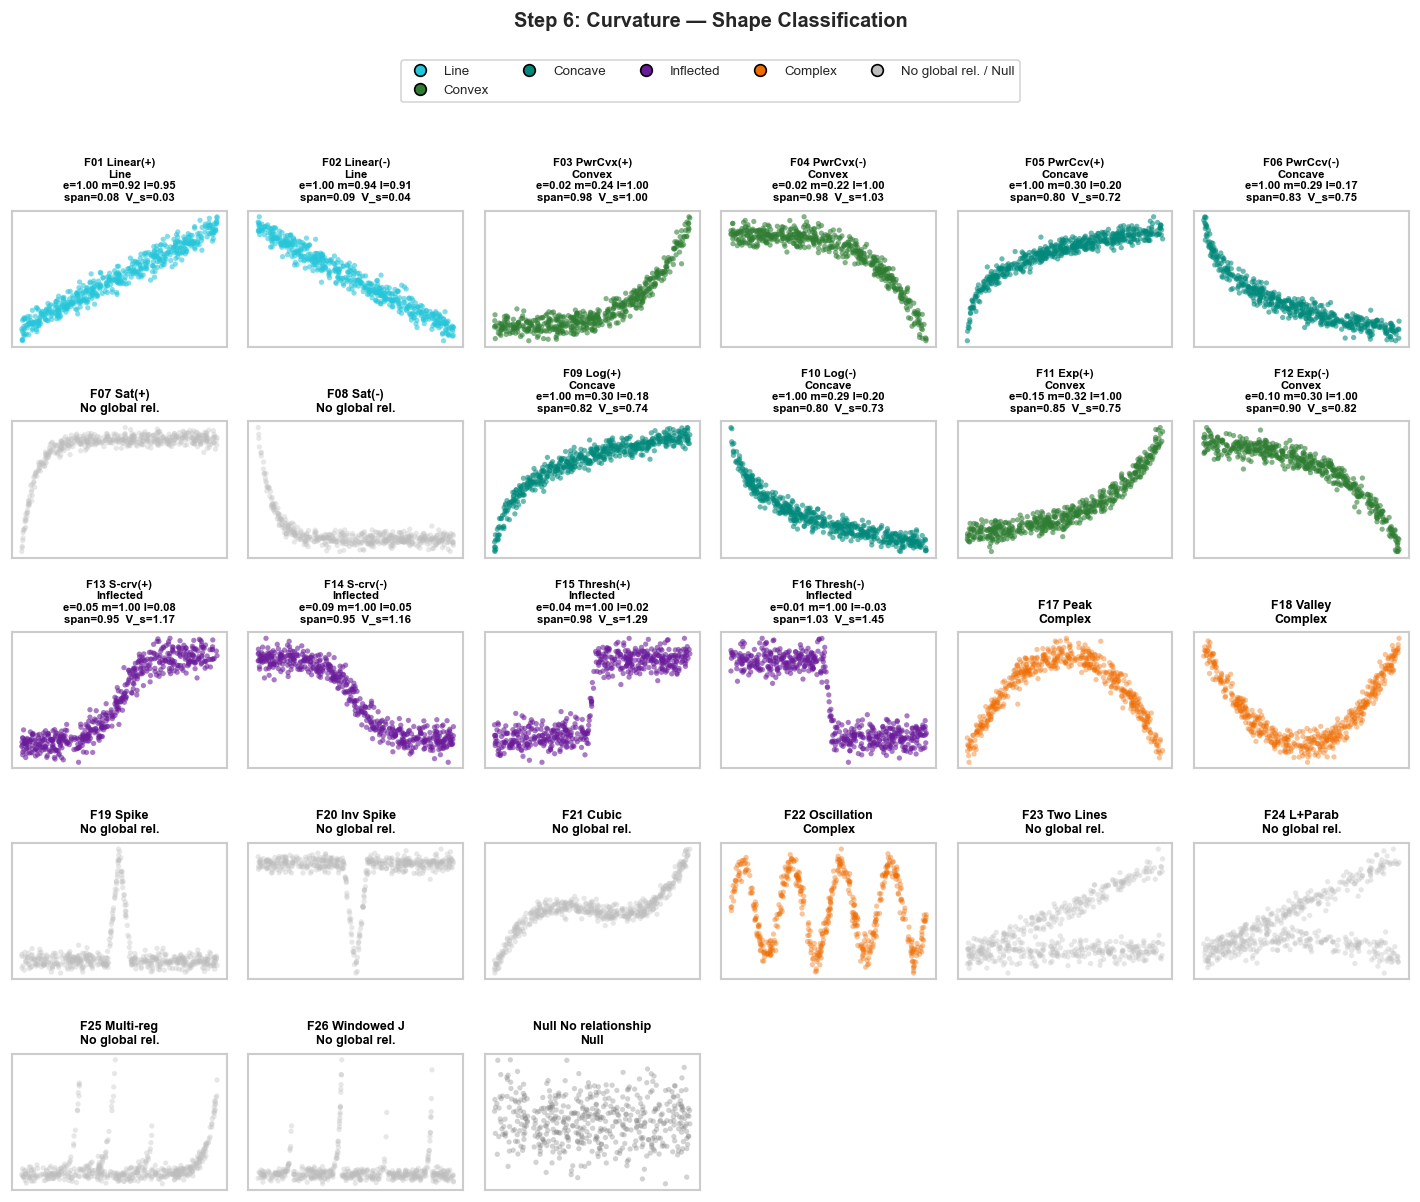

In [625]:
# ── Plot Step 6: Curvature ──
for col in ['shape_tree', 'slope_Vs']:
    cases_27 = cases_27.drop(columns=[col], errors='ignore')
cases_27 = cases_27.merge(
    simple_cases_27[['case_id', 'shape_tree', 'slope_Vs']], on='case_id', how='left')

SHAPE_MAP = {'Line': C_LINE, 'Convex': C_CONVEX, 'Concave': C_CONCAVE,
             'Inflected': C_INFLECTED, 'Weak/Uncertain': C_WEAK}

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Step 6: Curvature — Shape Classification',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['shape_tree']
        color = SHAPE_MAP.get(label, C_WEAK)
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label, color, alpha = 'Complex', C_COMPLEX, 0.40
    elif row['family_id'] == 'Null':
        label, color, alpha = 'Null', C_NULL, 0.35
    else:
        label, color, alpha = 'No global rel.', C_NO_REL, 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')

    if row['simple_complex_label'] == 'Simple':
        ax.set_title(
            f"{row['family_id']} {row['short']}\n{label}\n"
            f"e={row['e_d']:.2f} m={row['m_d']:.2f} l={row['l_d']:.2f}\n"
            f"span={row['slope_span']:.2f}  V_s={row['slope_Vs']:.2f}",
            fontsize=6.8, fontweight='bold', color='black')
    else:
        ax.set_title(f"{row['family_id']} {row['short']}\n{label}",
                     fontsize=7.5, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

shape_legend = [(k, SHAPE_MAP[k]) for k in SHAPE_MAP if k in set(cases_27['shape_tree'].dropna())]
shape_legend += [('Complex', C_COMPLEX), ('No global rel. / Null', C_NO_REL)]
handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=7, label=k) for k, c in shape_legend]
fig.legend(handles=handles, loc='upper center', ncol=min(5, len(handles)),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Final — Combined Tree Result

Global → Simple/Complex → Direction → Monotonicity → Line Detection → Curvature

In [626]:
# ── Final tree label ──
cases_27['final_tree_label'] = np.select(
    [cases_27['family_id'] == 'Null',
     cases_27['simple_complex_label'] == 'No global relationship',
     cases_27['simple_complex_label'] == 'Complex',
     cases_27['simple_complex_label'] == 'Simple'],
    ['Null', 'No global relationship', 'Complex',
     cases_27['shape_tree'].fillna('Simple: unclassified')],
    default='Unclassified'
)

print('═══ Final Tree Classification ═══')
print(cases_27['final_tree_label'].value_counts(dropna=False).to_string())

═══ Final Tree Classification ═══
final_tree_label
No global relationship    9
Convex                    4
Concave                   4
Inflected                 4
Complex                   3
Line                      2
Null                      1


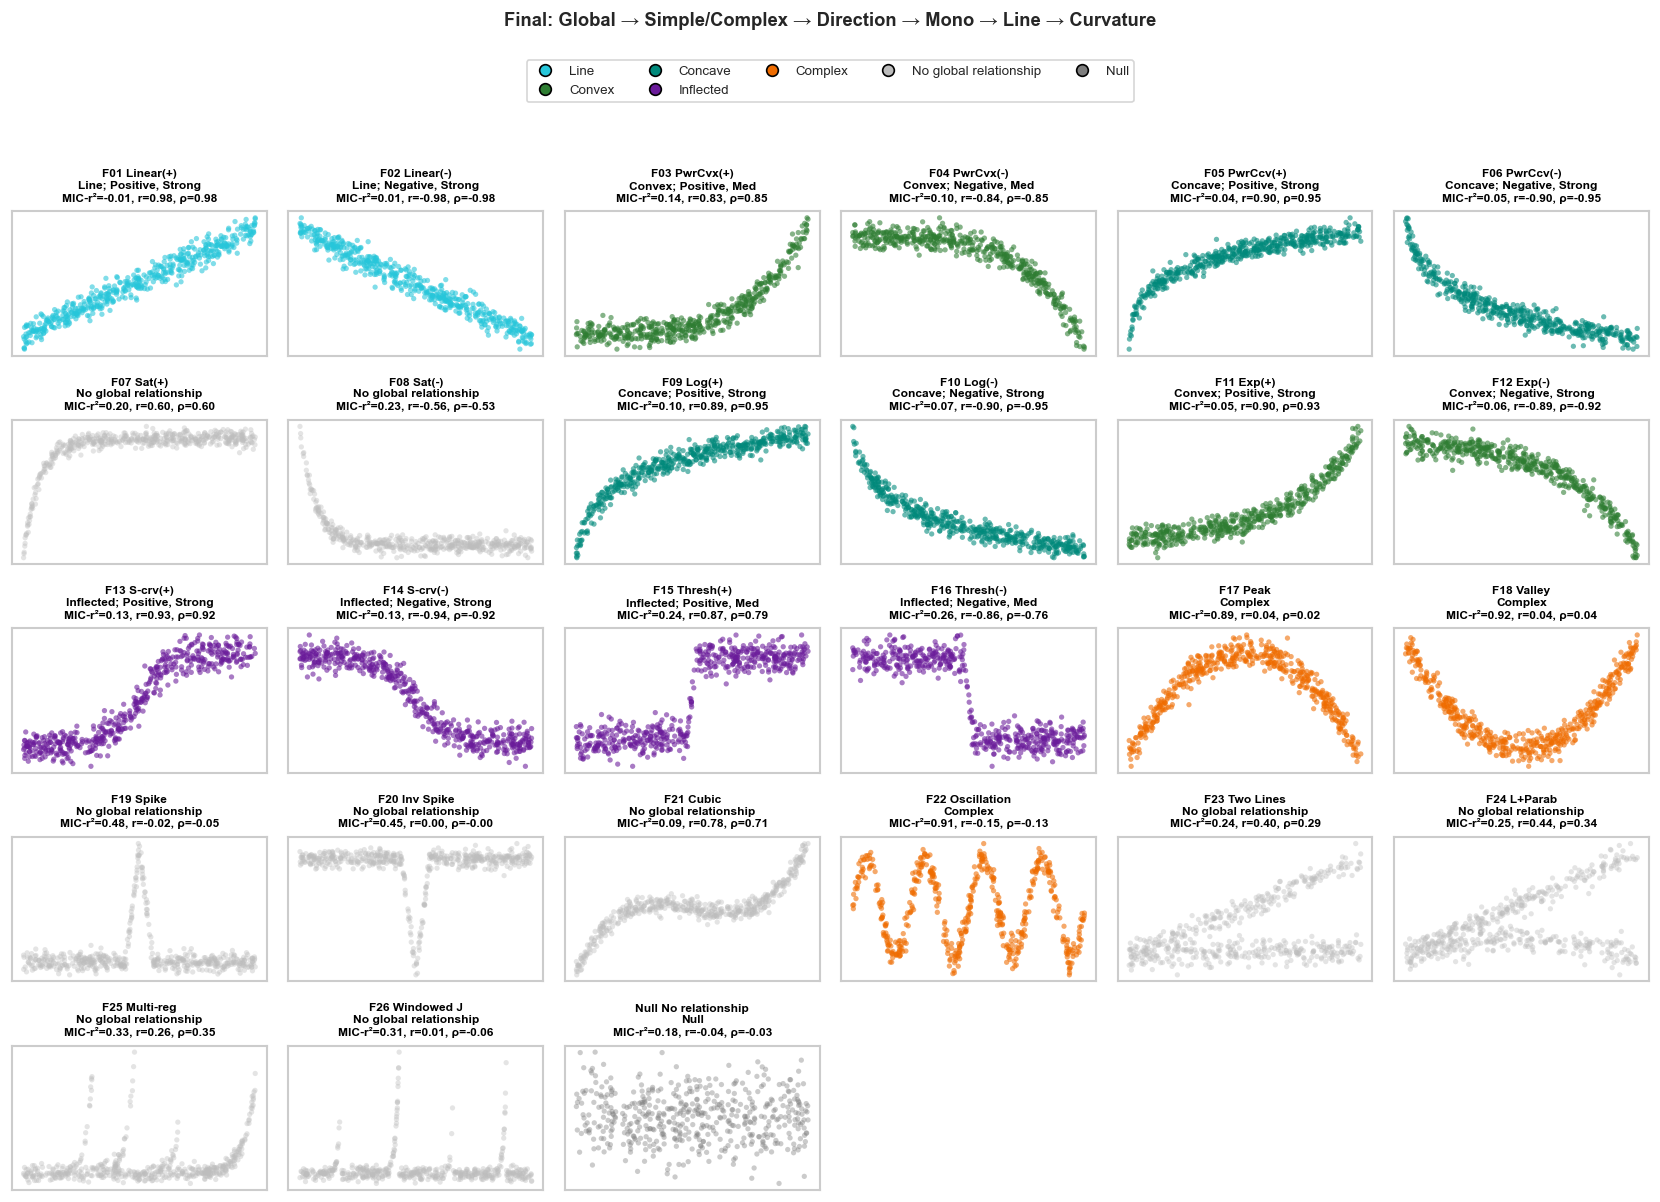

In [627]:
# ── Plot Final: Combined tree result ──
FINAL_MAP = {
    'Line': C_LINE, 'Convex': C_CONVEX, 'Concave': C_CONCAVE,
    'Inflected': C_INFLECTED, 'Weak/Uncertain': C_WEAK,
    'Simple: unclassified': C_WEAK,
    'Complex': C_COMPLEX, 'No global relationship': C_NO_REL, 'Null': C_NULL,
}

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Final: Global → Simple/Complex → Direction → Mono → Line → Curvature',
             fontsize=11, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['final_tree_label']
    color = FINAL_MAP.get(label, '#424242')
    alpha = 0.58 if label not in ['No global relationship', 'Null'] else 0.40

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')

    if row['simple_complex_label'] == 'Simple':
        subtitle = f"{label}; {row['direction_tree']}, {row['monotonicity_tree']}"
    else:
        subtitle = label

    ax.set_title(
        f"{row['family_id']} {row['short']}\n{subtitle}\n"
        f"MIC-r²={row['MIC_minus_r2']:.2f}, r={row['pearson_r']:.2f}, ρ={row['spearman_rho']:.2f}",
        fontsize=7.2, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=FINAL_MAP[k], markersize=7, label=k)
           for k in FINAL_MAP if k in set(cases_27['final_tree_label'])]
fig.legend(handles=handles, loc='upper center', ncol=min(5, len(handles)),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [628]:
# ── Final classification summary ──
summary_cols = [
    'family_id', 'short', 'global_label', 'simple_complex_label',
    'direction_tree', 'monotonicity_tree', 'is_line',
    'shape_tree', 'final_tree_label',
    'MIC', 'distance_correlation', 'MIC_minus_r2',
    'pearson_r', 'spearman_rho', 'slope_span', 'slope_Vs',
]

display(cases_27[summary_cols].round(3))

,family_id,short,global_label,simple_complex_label,direction_tree,monotonicity_tree,is_line,shape_tree,final_tree_label,MIC,distance_correlation,MIC_minus_r2,pearson_r,spearman_rho,slope_span,slope_Vs
0,F01,Linear(+),Global relationship,Simple,Positive,Strong,True,Line,Line,0.944,0.973,-0.010,0.977,0.978,0.078,0.034
1,F02,Linear(-),Global relationship,Simple,Negative,Strong,True,Line,Line,0.967,0.973,0.011,-0.978,-0.978,0.086,0.038
2,F03,PwrCvx(+),Global relationship,Simple,Positive,Med,False,Convex,Convex,0.830,0.864,0.139,0.832,0.850,0.979,1.003
3,F04,PwrCvx(-),Global relationship,Simple,Negative,Med,False,Convex,Convex,0.803,0.870,0.104,-0.836,-0.848,0.982,1.028
4,F05,PwrCcv(+),Global relationship,Simple,Positive,Strong,False,Concave,Concave,0.842,0.926,0.040,0.896,0.945,0.803,0.717
5,F06,PwrCcv(-),Global relationship,Simple,Negative,Strong,False,Concave,Concave,0.862,0.926,0.051,-0.901,-0.955,0.832,0.754
6,F07,Sat(+),No global relationship,No global relationship,NaN,NaN,NaN,NaN,No global relationship,0.558,0.642,0.201,0.597,0.603,NaN,NaN
7,F08,Sat(-),No global relationship,No global relationship,NaN,NaN,NaN,NaN,No global relationship,0.550,0.617,0.234,-0.562,-0.531,NaN,NaN
8,F09,Log(+),Global relationship,Simple,Positive,Strong,False,Concave,Concave,0.887,0.921,0.096,0.889,0.952,0.819,0.736
9,F10,Log(-),Global relationship,Simple,Negative,Strong,False,Concave,Concave,0.883,0.926,0.069,-0.902,-0.955,0.804,0.725


Step filter split summary:


,step,base_n,selected_n,filtered_out_n
0,Step 1: Global Relationship,26,17,9
1,Step 2: Simple vs Complex,17,14,3
2,Step 3: Direction,14,7,7
3,Step 4: Monotonicity,14,10,4
4,Step 5: Line Detection,10,2,8
5,Step 6: Curvature,12,12,0


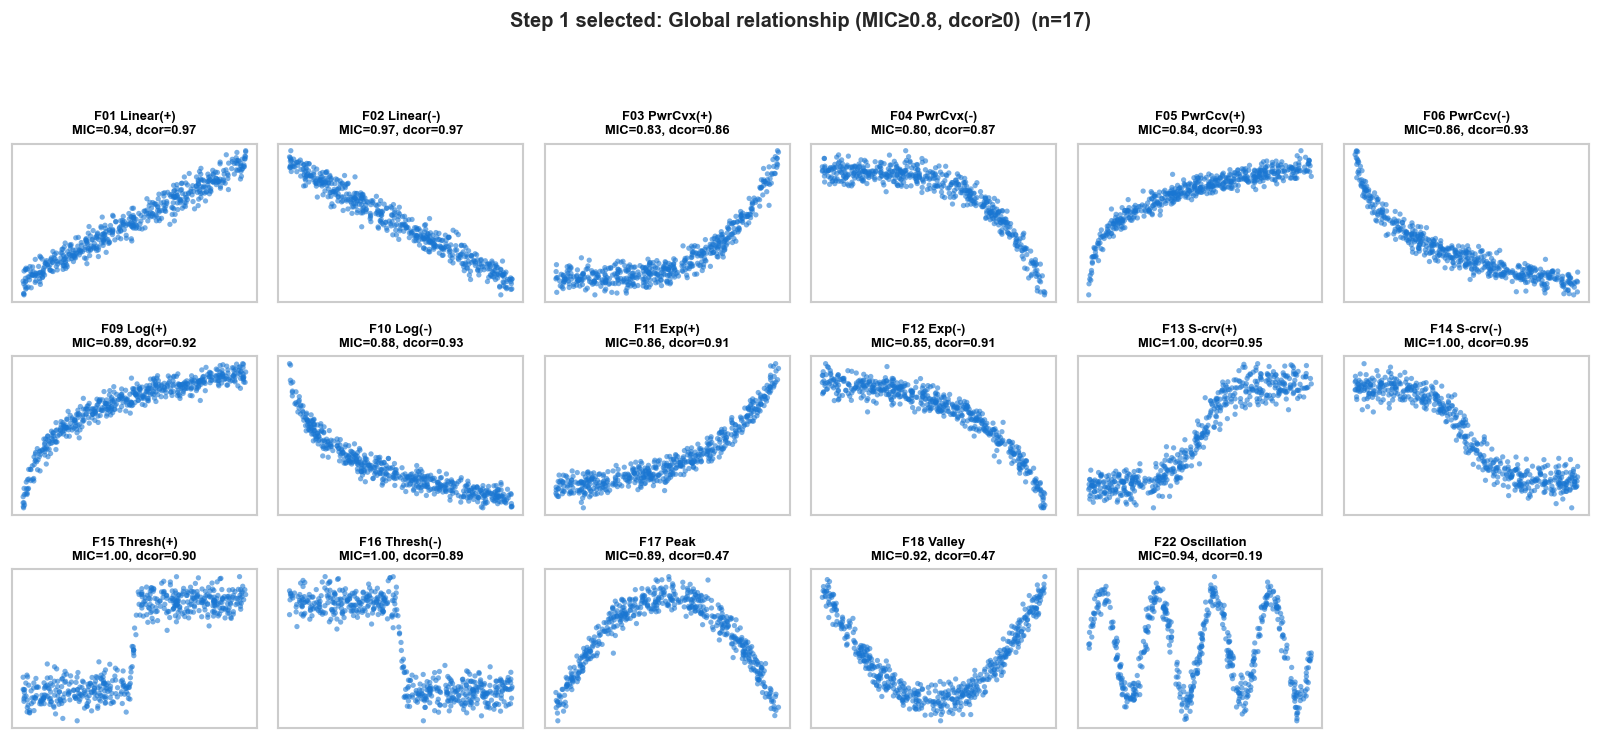

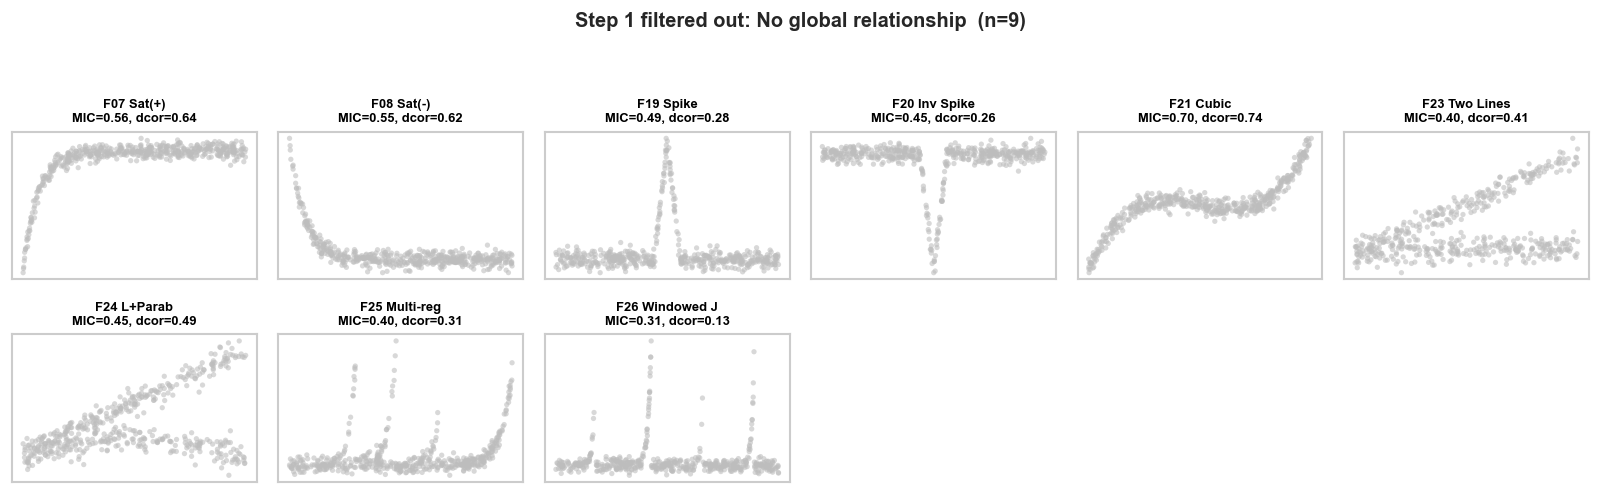

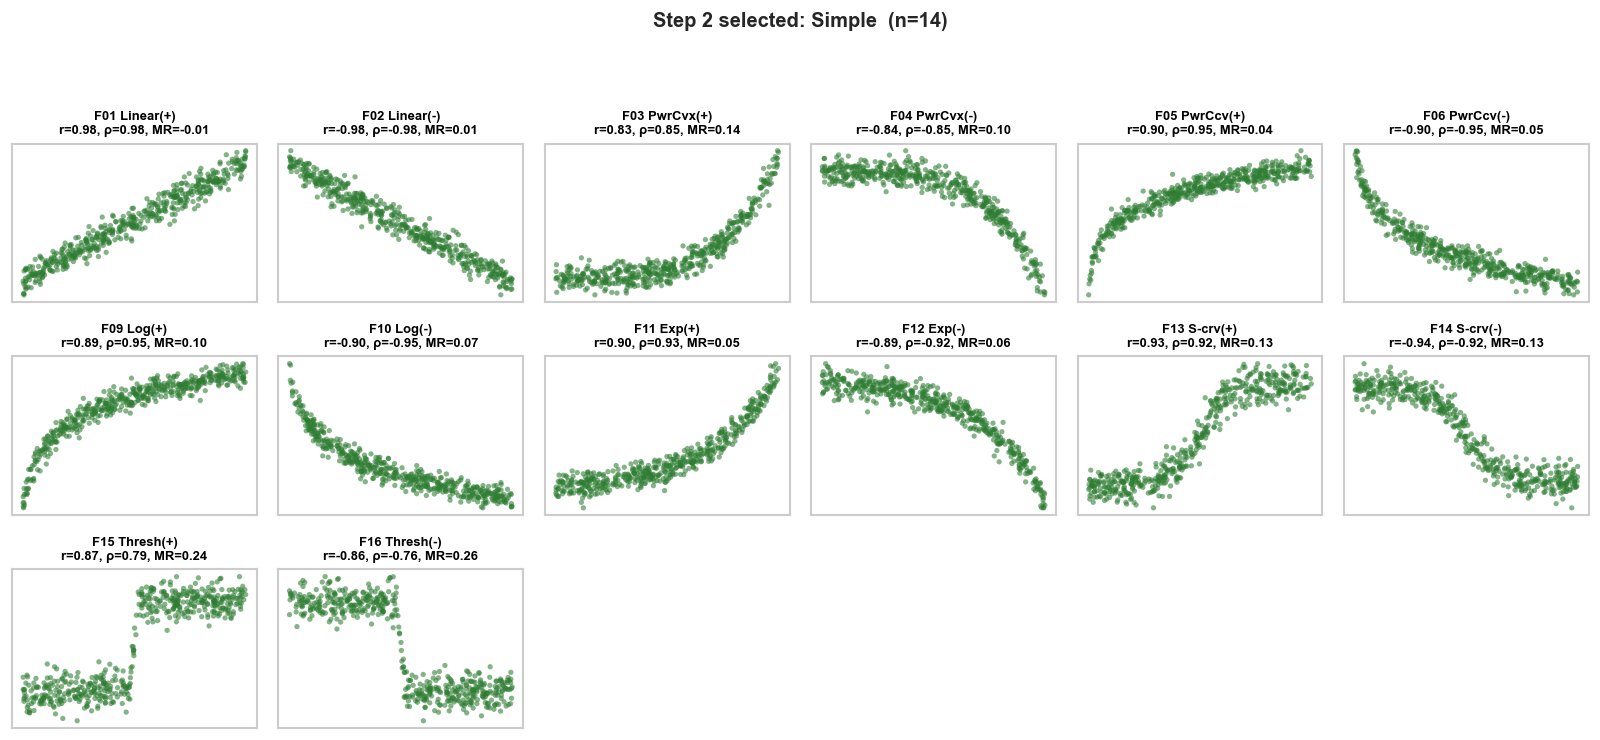

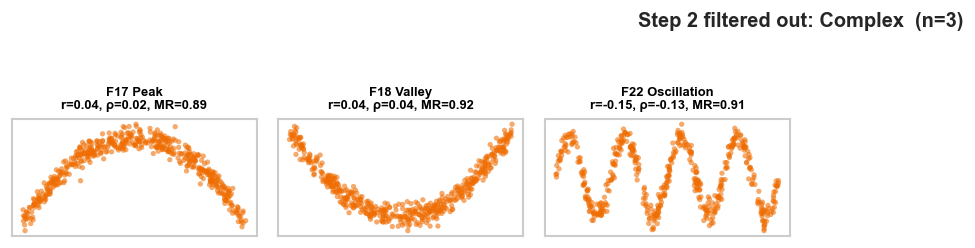

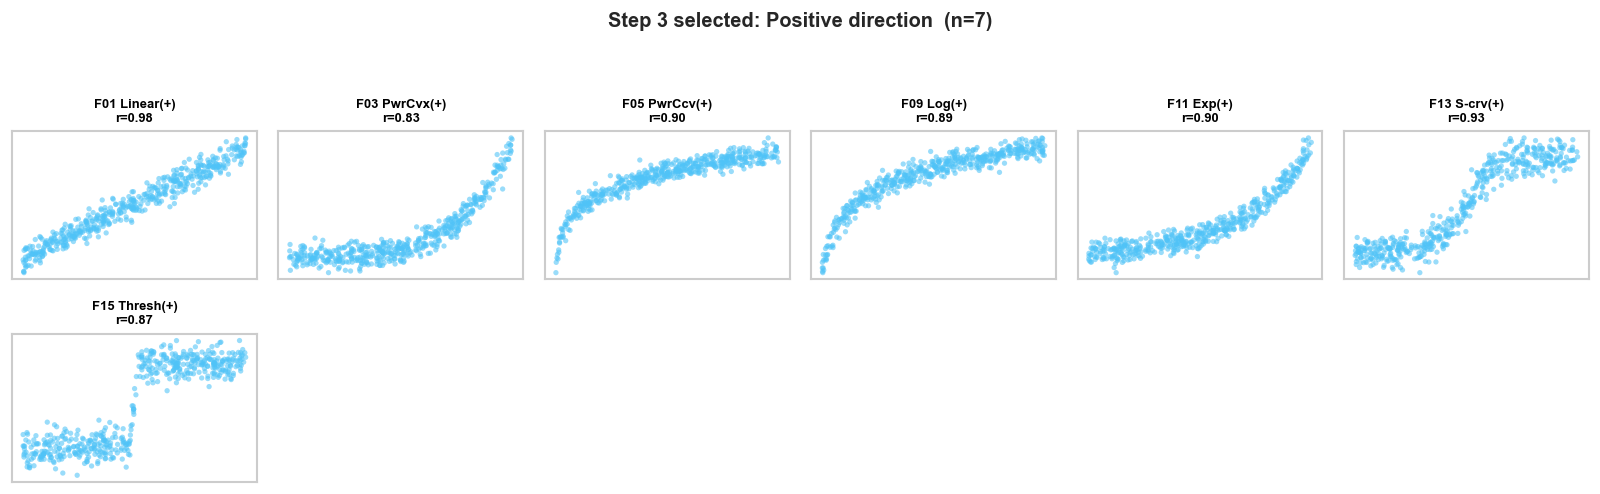

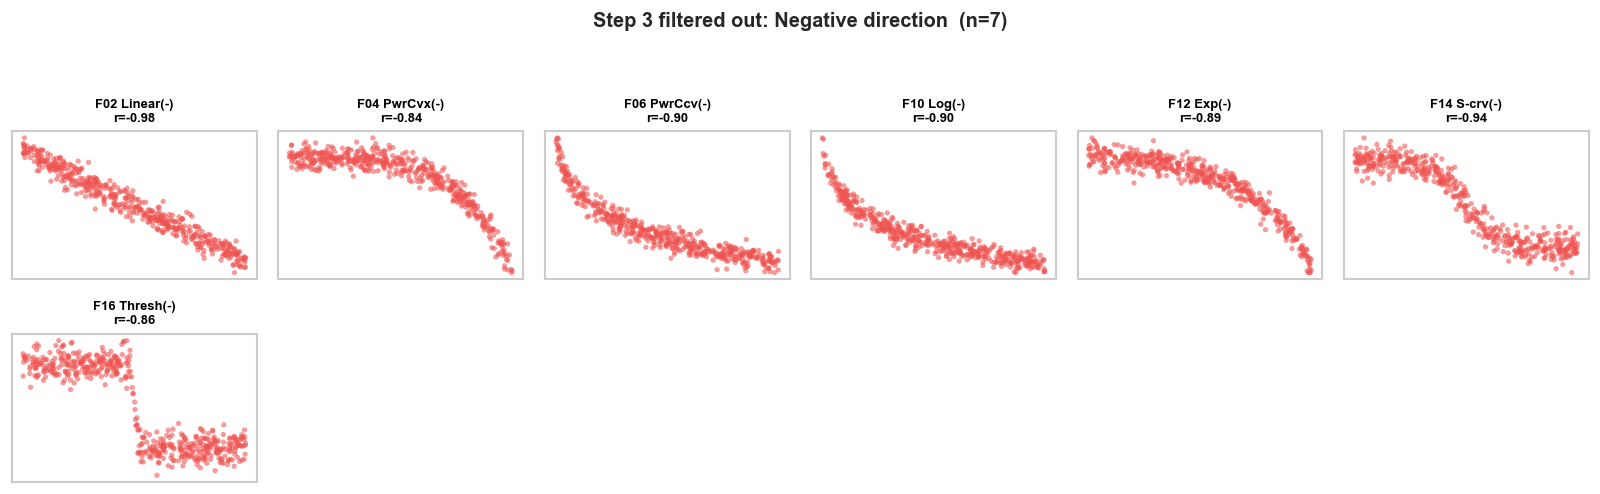

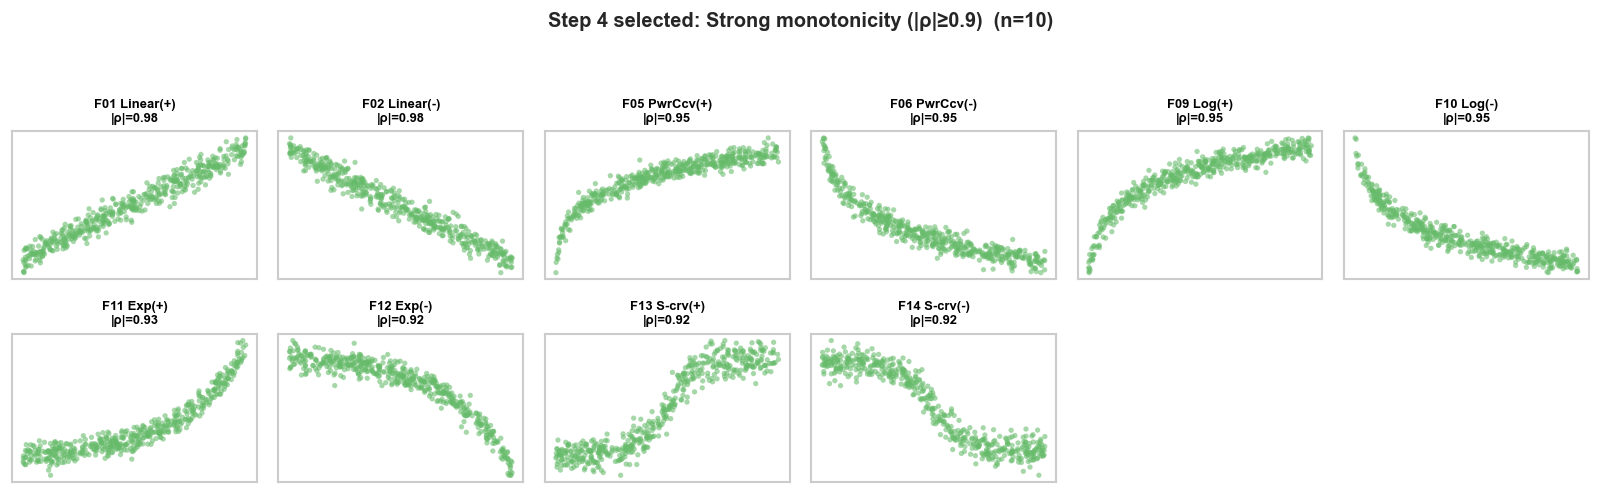

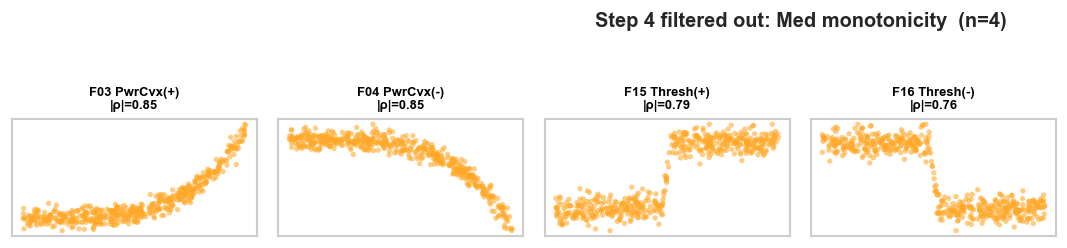

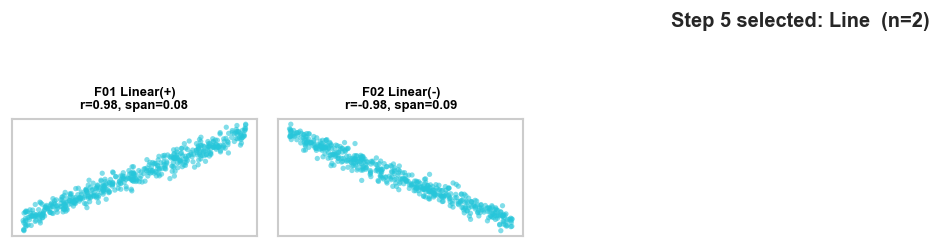

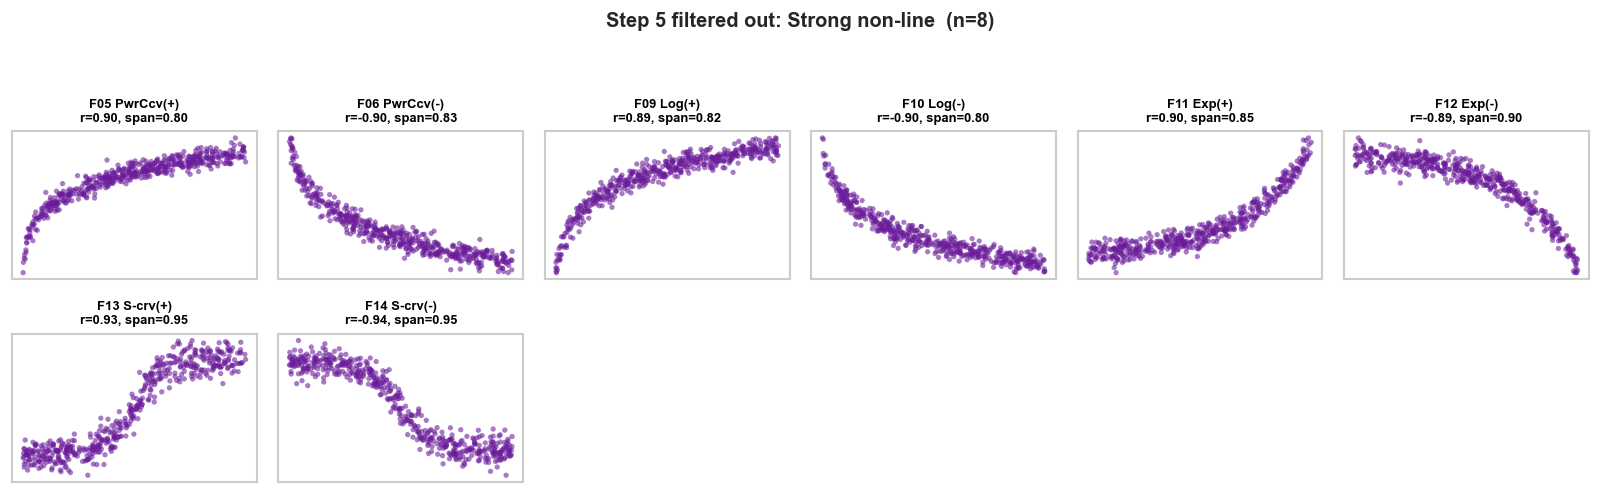

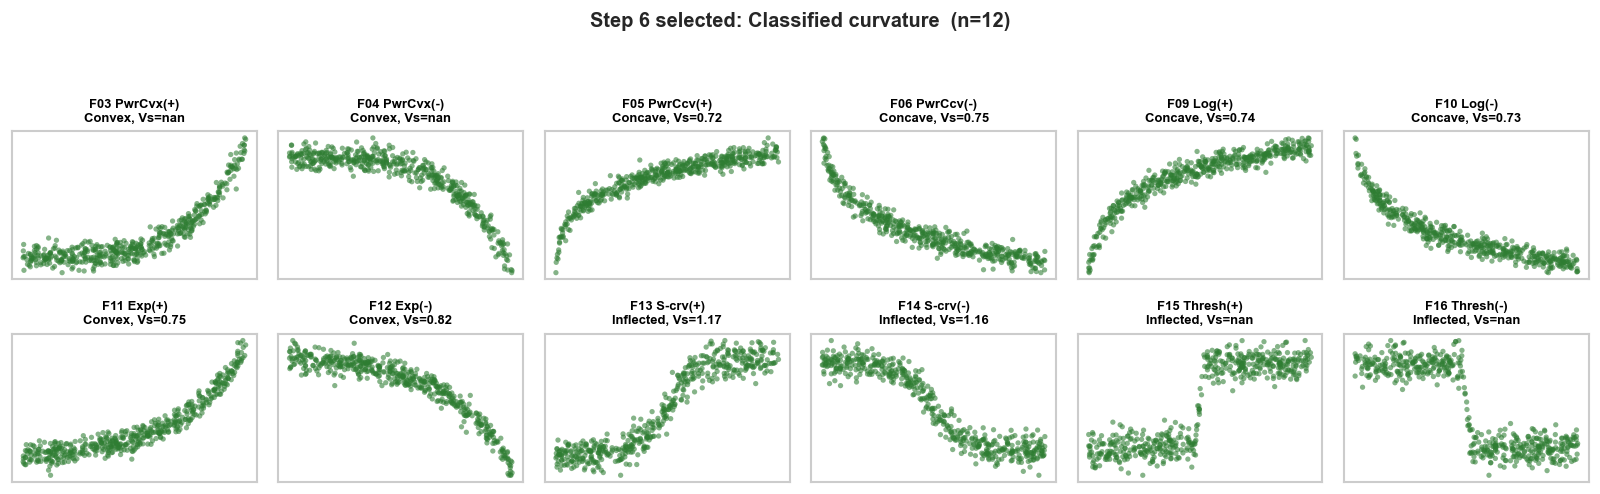

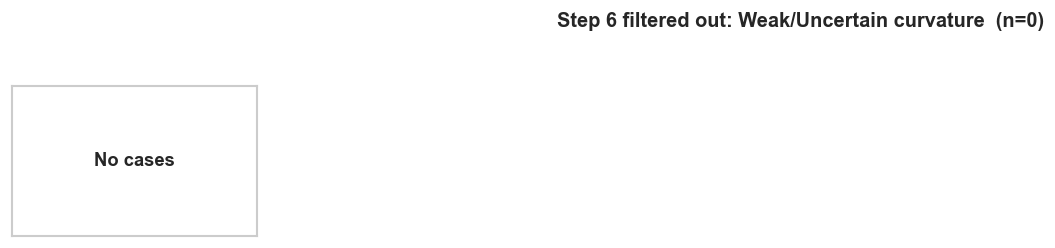

In [654]:
# ── Step filter split plots: selected vs filtered out ──
# Run this after Step 6 / Final cells so all tree columns exist in cases_27.
if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

_required_cols = [
    'case_id', 'family_id', 'short', 'global_relationship', 'simple_complex_label',
    'direction_tree', 'monotonicity_tree', 'is_line', 'shape_tree',
    'MIC', 'distance_correlation', 'pearson_r', 'spearman_rho'
]
_missing = [c for c in _required_cols if c not in cases_27.columns]
if _missing:
    raise ValueError(f'Missing columns for step split plots: {_missing}. Run the earlier tree cells first.')


def _as_bool_mask(mask):
    return pd.Series(mask, index=cases_27.index).fillna(False).astype(bool)


def _fmt_snr(v):
    return '∞' if v == float('inf') else f'{v:g}'


def _plot_case_subset(title, mask, color, subtitle_fn=None, ncols=6, point_size=10):
    mask = _as_bool_mask(mask)
    rows = cases_27[mask].copy()
    n = len(rows)
    nrows = max(1, math.ceil(max(n, 1) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.25 * ncols, 2.05 * nrows), squeeze=False)
    axes_flat = axes.ravel()
    fig.suptitle(f'{title}  (n={n})', fontsize=12, fontweight='bold', y=1.0)

    for ax, (_, row) in zip(axes_flat, rows.iterrows()):
        idx = case_idx_by_id.get(row['case_id'])
        if idx is not None:
            ax.scatter(x_all[idx], y_all[idx], s=point_size, alpha=0.58,
                       color=color, edgecolors='none')
        if subtitle_fn is None:
            subtitle = f"SNR={_fmt_snr(row['snr_val'])}, rep={int(row['replicate'])}"
        else:
            subtitle = subtitle_fn(row)
        ax.set_title(f"{row['family_id']} {row['short']}\n{subtitle}",
                     fontsize=7.8, fontweight='bold', color='black')
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    if n == 0:
        axes_flat[0].set_visible(True)
        axes_flat[0].text(0.5, 0.5, 'No cases', ha='center', va='center', fontsize=11, fontweight='bold')
        axes_flat[0].set_xticks([])
        axes_flat[0].set_yticks([])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


_step_specs = [
    {
        'name': 'Step 1: Global Relationship',
        'base': cases_27['family_id'] != 'Null',
        'selected': cases_27['global_relationship'],
        'selected_title': f'Step 1 selected: Global relationship (MIC≥{MIC_THRESH}, dcor≥{DCOR_THRESH})',
        'filtered_title': 'Step 1 filtered out: No global relationship',
        'selected_color': C_GLOBAL,
        'filtered_color': C_NO_REL,
        'subtitle': lambda r: f"MIC={r['MIC']:.2f}, dcor={r['distance_correlation']:.2f}",
    },
    {
        'name': 'Step 2: Simple vs Complex',
        'base': cases_27['global_relationship'],
        'selected': cases_27['simple_complex_label'] == 'Simple',
        'selected_title': 'Step 2 selected: Simple',
        'filtered_title': 'Step 2 filtered out: Complex',
        'selected_color': C_SIMPLE,
        'filtered_color': C_COMPLEX,
        'subtitle': lambda r: f"r={r['pearson_r']:.2f}, ρ={r['spearman_rho']:.2f}, MR={r['MIC_minus_r2']:.2f}",
    },
    {
        'name': 'Step 3: Direction',
        'base': cases_27['simple_complex_label'] == 'Simple',
        'selected': cases_27['direction_tree'] == 'Positive',
        'selected_title': 'Step 3 selected: Positive direction',
        'filtered_title': 'Step 3 filtered out: Negative direction',
        'selected_color': C_POS,
        'filtered_color': C_NEG,
        'subtitle': lambda r: f"r={r['pearson_r']:.2f}",
    },
    {
        'name': 'Step 4: Monotonicity',
        'base': cases_27['simple_complex_label'] == 'Simple',
        'selected': cases_27['monotonicity_tree'] == 'Strong',
        'selected_title': f'Step 4 selected: Strong monotonicity (|ρ|≥{MONO_STRONG})',
        'filtered_title': 'Step 4 filtered out: Med monotonicity',
        'selected_color': C_MONO_S,
        'filtered_color': C_MONO_M,
        'subtitle': lambda r: f"|ρ|={abs(r['spearman_rho']):.2f}",
    },
    {
        'name': 'Step 5: Line Detection',
        'base': (cases_27['simple_complex_label'] == 'Simple') & (cases_27['monotonicity_tree'] == 'Strong'),
        'selected': cases_27['is_line'] == True,
        'selected_title': 'Step 5 selected: Line',
        'filtered_title': 'Step 5 filtered out: Strong non-line',
        'selected_color': C_LINE,
        'filtered_color': C_NONLINE,
        'subtitle': lambda r: f"r={r['pearson_r']:.2f}, span={r.get('slope_span', np.nan):.2f}",
    },
    {
        'name': 'Step 6: Curvature',
        'base': (cases_27['simple_complex_label'] == 'Simple') & (cases_27['is_line'] != True),
        'selected': cases_27['shape_tree'].isin(['Convex', 'Concave', 'Inflected']),
        'selected_title': 'Step 6 selected: Classified curvature',
        'filtered_title': 'Step 6 filtered out: Weak/Uncertain curvature',
        'selected_color': C_CONVEX,
        'filtered_color': C_WEAK,
        'subtitle': lambda r: f"{r['shape_tree']}, Vs={r.get('slope_Vs', np.nan):.2f}",
    },
]

_summary_rows = []
for spec in _step_specs:
    base = _as_bool_mask(spec['base'])
    selected = base & _as_bool_mask(spec['selected'])
    filtered = base & ~_as_bool_mask(spec['selected'])
    _summary_rows.append({
        'step': spec['name'],
        'base_n': int(base.sum()),
        'selected_n': int(selected.sum()),
        'filtered_out_n': int(filtered.sum()),
    })

print('Step filter split summary:')
display(pd.DataFrame(_summary_rows))

for spec in _step_specs:
    base = _as_bool_mask(spec['base'])
    selected = base & _as_bool_mask(spec['selected'])
    filtered = base & ~_as_bool_mask(spec['selected'])
    _plot_case_subset(spec['selected_title'], selected, spec['selected_color'], spec['subtitle'])
    _plot_case_subset(spec['filtered_title'], filtered, spec['filtered_color'], spec['subtitle'])
